In [1]:
import os
import ctypes

# Manually load libnvrtc.so.13 and libnvrtc-builtins.so.13.0 using ctypes
# This is necessary to bypass LD_LIBRARY_PATH issues in Jupyter for CuPy/RAPIDS
try:
    base_path = "/home/caspar/APS_project/.venv/lib/python3.12/site-packages/nvidia/cu13/lib"
    
    # Load libnvrtc.so.13
    nvrtc_path = os.path.join(base_path, "libnvrtc.so.13")
    if os.path.exists(nvrtc_path):
        ctypes.CDLL(nvrtc_path)
        print(f"Successfully loaded {nvrtc_path}")
    else:
        print(f"Warning: {nvrtc_path} does not exist")

    # Load libnvrtc-builtins.so.13.0
    builtins_path = os.path.join(base_path, "libnvrtc-builtins.so.13.0")
    if os.path.exists(builtins_path):
        ctypes.CDLL(builtins_path)
        print(f"Successfully loaded {builtins_path}")
    else:
        print(f"Warning: {builtins_path} does not exist")
        
except Exception as e:
    print(f"Failed to load libraries: {e}")

import cupy
import cuml

Successfully loaded /home/caspar/APS_project/.venv/lib/python3.12/site-packages/nvidia/cu13/lib/libnvrtc.so.13
Successfully loaded /home/caspar/APS_project/.venv/lib/python3.12/site-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0


In [2]:
import os
import sys

# Add the path to libnvrtc.so.13 to LD_LIBRARY_PATH
# This is necessary because CuPy needs to find this library at runtime
venv_path = "/home/caspar/APS_project/.venv"
nvrtc_path = os.path.join(venv_path, "lib/python3.12/site-packages/nvidia/cu13/lib")

if os.path.exists(nvrtc_path):
    current_ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    if nvrtc_path not in current_ld_library_path:
        os.environ["LD_LIBRARY_PATH"] = f"{current_ld_library_path}:{nvrtc_path}"
        print(f"Added {nvrtc_path} to LD_LIBRARY_PATH")
else:
    print(f"Warning: Could not find {nvrtc_path}")

# Also try adding to sys.path just in case, though LD_LIBRARY_PATH is usually what matters for .so files
if nvrtc_path not in sys.path:
    sys.path.append(nvrtc_path)

Added /home/caspar/APS_project/.venv/lib/python3.12/site-packages/nvidia/cu13/lib to LD_LIBRARY_PATH


# 多家庭lstm


数据提取

In [3]:
import numpy as np
import pandas as pd
import glob
import os

# 查找所有CSV文件
csv_files = glob.glob('./Data-PecanStreet/*.csv')

# 读取并合并所有CSV文件
data_list = []
for file in csv_files:
    df = pd.read_csv(file)
    print(f"成功读取 {file}: {df.shape}")
    df['local_15min'] = pd.to_datetime(df['local_15min'], utc=True)
    df = df.resample('h', on='local_15min').mean().reset_index()  # 按小时重采样并计算均值
    df['dataid'] = os.path.basename(file).split('.')[0]  # 从文件名提取dataid
    data_list.append(df)

# 合并所有数据
data = pd.concat(data_list, ignore_index=True)

# 数据预处理
data = data.fillna(value=0)
data = data[['dataid','local_15min','grid']].reset_index(drop=True)

print(data.head())


成功读取 ./Data-PecanStreet/661.csv: (35032, 79)
成功读取 ./Data-PecanStreet/8386.csv: (35036, 79)
成功读取 ./Data-PecanStreet/8386.csv: (35036, 79)
成功读取 ./Data-PecanStreet/9278.csv: (35035, 79)
成功读取 ./Data-PecanStreet/9278.csv: (35035, 79)
成功读取 ./Data-PecanStreet/7951.csv: (35036, 79)
成功读取 ./Data-PecanStreet/7951.csv: (35036, 79)
成功读取 ./Data-PecanStreet/8565.csv: (35036, 79)
成功读取 ./Data-PecanStreet/8565.csv: (35036, 79)
成功读取 ./Data-PecanStreet/3538.csv: (35036, 79)
成功读取 ./Data-PecanStreet/3538.csv: (35036, 79)
成功读取 ./Data-PecanStreet/9922.csv: (35036, 79)
成功读取 ./Data-PecanStreet/9922.csv: (35036, 79)
成功读取 ./Data-PecanStreet/6139.csv: (35036, 79)
成功读取 ./Data-PecanStreet/6139.csv: (35036, 79)
成功读取 ./Data-PecanStreet/4031.csv: (35036, 79)
成功读取 ./Data-PecanStreet/3039.csv: (35036, 79)
成功读取 ./Data-PecanStreet/4031.csv: (35036, 79)
成功读取 ./Data-PecanStreet/3039.csv: (35036, 79)
  dataid               local_15min     grid
0    661 2018-01-01 06:00:00+00:00  0.00000
1    661 2018-01-01 07:00:00+00:00  1.5

家庭嵌入

In [4]:
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

SEQ_LEN = 24  # 使用24小时滑动窗口

# ==========================================
# 1. 定义多家庭时序数据集类
# ==========================================
class MultiHouseholdSequenceDataset(Dataset):
    def __init__(self, data, household_codes, seq_len=SEQ_LEN):
        """
        多家庭时序数据集
        data: 归一化后的用电量数据 (N,)
        household_codes: 对应的家庭ID编码 (N,)
        """
        self.data = torch.tensor(data, dtype=torch.float32).unsqueeze(-1) # [N, 1]
        self.household_codes = torch.tensor(household_codes, dtype=torch.long)
        self.seq_len = seq_len
        
        # 预计算有效索引，排除跨家庭边界的样本
        self.valid_indices = []
        # print(f"正在筛选有效样本（排除跨家庭边界的序列）...")
        
        # 只需要遍历一次即可构建索引
        # 只有当序列的开始(idx)和结束(idx+seq_len)属于同一个家庭时，才是有效样本
        # 利用numpy操作加速判断（如果数据量非常大，循环会慢，这里保留循环逻辑但优化写法）
        for idx in range(len(self.data) - self.seq_len):
            if self.household_codes[idx] == self.household_codes[idx + self.seq_len]:
                self.valid_indices.append(idx)
        
        # print(f"原始数据点数: {len(self.data)}")
        # print(f"有效样本数: {len(self.valid_indices)}")
        
    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        # 使用有效索引获取真实位置
        actual_idx = self.valid_indices[idx]
        
        # 输入序列 x: [seq_len]
        x = self.data[actual_idx : actual_idx + self.seq_len].squeeze(-1) 
        # 目标值 y: 标量
        y = self.data[actual_idx + self.seq_len].squeeze(-1)
        # 对应的家庭ID (取目标时刻的家庭ID)
        household_id = self.household_codes[actual_idx + self.seq_len]
        
        return x, household_id, y

# ==========================================
# 2. 数据准备与划分函数 (修复数据泄露与ID映射)
# ==========================================
def prepare_multihousehold_data(data, train_ratio=0.8, seq_len=SEQ_LEN, min_data_points=100):
    """
    按家庭分别划分训练和验证集，防止数据泄露，并确保ID映射一致性。
    1. 先划分 Train/Val。
    2. 仅在 Train 上 fit Scaler。
    3. 用该 Scaler 转换 Train 和 Val。
    """
    print(f"=== 数据预处理: 划分数据集与防泄露归一化 (seq_len={seq_len}) ===")
    
    # 1. 筛选有效家庭
    unique_households = data['dataid'].unique()
    valid_households = []
    
    for household_id in unique_households:
        count = len(data[data['dataid'] == household_id])
        # 过滤条件：数据点足够多且ID不是0
        if count >= min_data_points and str(household_id) != '0.0':
            valid_households.append(household_id)
    
    # [关键修复] 显式排序，确保每次运行ID映射一致
    valid_households = sorted(valid_households)
    print(f"有效家庭数量: {len(valid_households)}")
    print(f"有效家庭列表 (已排序): {valid_households}")
    
    # [关键修复] 建立固定的家庭ID映射表
    household_map = {hid: i for i, hid in enumerate(valid_households)}
    
    # 初始化容器
    train_grid_list = []
    train_code_list = []
    val_grid_list = []
    val_code_list = []
    
    household_scalers = {}
    
    # 2. 逐个家庭处理
    for household_id in valid_households:
        # 提取该家庭数据
        df_sub = data[data['dataid'] == household_id].copy()
        
        # 简单的缺失值处理 (ffill + bfill)
        if df_sub['grid'].isna().any():
            df_sub['grid'] = df_sub['grid'].ffill().bfill()
            
        grid_values = df_sub['grid'].values.reshape(-1, 1)
        
        # 计算划分点
        n_samples = len(grid_values)
        train_size = int(n_samples * train_ratio)
        
        # 确保训练集至少能构成一个序列
        if train_size <= seq_len:
            print(f"警告: 家庭 {household_id} 数据过少，跳过。")
            continue
            
        # [关键修复] 先划分数据
        train_raw = grid_values[:train_size]
        val_raw = grid_values[train_size:]
        
        # [关键修复] 仅在训练集上 Fit 归一化器
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaler.fit(train_raw)
        
        # 保存归一化器
        household_scalers[household_id] = scaler
        
        # 转换训练集和验证集
        train_norm = scaler.transform(train_raw).flatten()
        # 验证集可能为空（如果数据很少），做个保护
        if len(val_raw) > 0:
            val_norm = scaler.transform(val_raw).flatten()
        else:
            val_norm = np.array([])
            
        # 生成对应的家庭ID编码 (全为同一个ID)
        # 使用 household_map 确保 ID 稳定
        code_idx = household_map[household_id]
        train_codes = np.full(len(train_norm), code_idx, dtype=np.int64)
        val_codes = np.full(len(val_norm), code_idx, dtype=np.int64)
        
        # 添加到列表
        train_grid_list.append(train_norm)
        train_code_list.append(train_codes)
        
        if len(val_norm) > 0:
            val_grid_list.append(val_norm)
            val_code_list.append(val_codes)
            
        # print(f"家庭 {household_id}: 训练集 {len(train_norm)} | 验证集 {len(val_norm)}")

    # 3. 合并所有家庭的数据
    train_data_all = np.concatenate(train_grid_list)
    train_codes_all = np.concatenate(train_code_list)
    
    if len(val_grid_list) > 0:
        val_data_all = np.concatenate(val_grid_list)
        val_codes_all = np.concatenate(val_code_list)
    else:
        val_data_all = np.array([])
        val_codes_all = np.array([])
        
    print(f"\n=== 最终数据集统计 ===")
    print(f"训练集总点数: {len(train_data_all)}")
    print(f"验证集总点数: {len(val_data_all)}")
    
    return train_data_all, train_codes_all, val_data_all, val_codes_all, household_scalers, valid_households

# ==========================================
# 3. 执行数据准备与Dataset构建
# ==========================================
# 假设 'data' 变量已经在上一个单元格加载完毕
if 'data' in locals():
    # 调用处理函数
    train_data, train_household_codes, val_data, val_household_codes, household_scalers, valid_households = \
        prepare_multihousehold_data(data, train_ratio=0.8, seq_len=SEQ_LEN)

    # 获取有效家庭数量（用于模型定义）
    num_unique_households = len(valid_households)
    print(f"用于模型的家庭数量 (Embedding Size): {num_unique_households}")

    # 创建 PyTorch Dataset
    # seq_len 与上面保持一致
    train_dataset = MultiHouseholdSequenceDataset(train_data, train_household_codes, seq_len=SEQ_LEN)
    val_dataset = MultiHouseholdSequenceDataset(val_data, val_household_codes, seq_len=SEQ_LEN)

    print(f"\n=== 样本生成统计 ===")
    print(f"训练样本数 (Samples): {len(train_dataset)}")
    print(f"验证样本数 (Samples): {len(val_dataset)}")
    
    # 创建 DataLoader
    # batch_size = 256
    # train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    # val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
else:
    print("错误: 变量 'data' 未定义，请先运行数据读取单元格。")

=== 数据预处理: 划分数据集与防泄露归一化 (seq_len=24) ===
有效家庭数量: 10
有效家庭列表 (已排序): ['3039', '3538', '4031', '6139', '661', '7951', '8386', '8565', '9278', '9922']

=== 最终数据集统计 ===
训练集总点数: 70080
验证集总点数: 17520
用于模型的家庭数量 (Embedding Size): 10

=== 样本生成统计 ===
训练样本数 (Samples): 69840
验证样本数 (Samples): 17280

=== 样本生成统计 ===
训练样本数 (Samples): 69840
验证样本数 (Samples): 17280


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, ParameterGrid, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import torch.nn.functional as F
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')
# 设置中文字体，用于图表显示
plt.rcParams['font.sans-serif'] = ['SimHei']
# 设置正常显示负号
plt.rcParams['axes.unicode_minus'] = True

# 支持家庭嵌入的LSTM模型
class MultiHouseholdLSTMModel(nn.Module):
    def __init__(self, num_households, input_size=1, hidden_size=128, 
                 embedding_dim=16, num_layers=3, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding_dim = embedding_dim
        # 家庭嵌入层
        self.household_embedding = nn.Embedding(num_households, embedding_dim)
        # LSTM层处理时序数据
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        # 融合LSTM输出和家庭嵌入
        self.fusion_layer = nn.Linear(hidden_size + embedding_dim, hidden_size)
        # 输出层
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x, household_ids):
        # x: [batch_size, seq_len]
        # household_ids: [batch_size]
        # 处理时序数据
        x = x.unsqueeze(-1)  # [batch_size, seq_len, 1]
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]  # 取最后一个时间步 [batch_size, hidden_size]
        
        # 获取家庭嵌入
        household_emb = self.household_embedding(household_ids)  # [batch_size, embedding_dim]
        
        # 融合LSTM输出和家庭嵌入
        combined = torch.cat([lstm_out, household_emb], dim=1)  # [batch_size, hidden_size + embedding_dim]
        fused = self.relu(self.fusion_layer(combined))  # [batch_size, hidden_size]
        
        # 最终预测
        out = self.dropout(fused)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

# 创建数据加载器
batch_size = 4096
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)     
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 创建多家庭LSTM模型
model = MultiHouseholdLSTMModel(
    num_households=num_unique_households,
    input_size=1, 
    hidden_size=128, 
    embedding_dim=32,
    num_layers=3, 
    dropout=0.2
).to(device)

# 计算模型参数量
total_params = sum(p.numel() for p in model.parameters())
print(f"多家庭LSTM模型参数量: {total_params:,}")

# 优化器添加权重衰减
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
# loss_fn = nn.MSELoss()
loss_fn = nn.L1Loss()
# 学习率调度器
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

使用设备: cuda
多家庭LSTM模型参数量: 360,513
多家庭LSTM模型参数量: 360,513



开始训练多家庭LSTM模型...
训练集样本数: 69840
验证集样本数: 17280


Epoch 1/50 | Train Loss: 0.158212 | Val Loss: 0.073083 | LR: 0.001000


Epoch 2/50 | Train Loss: 0.113252 | Val Loss: 0.074722 | LR: 0.001000


Epoch 3/50 | Train Loss: 0.111222 | Val Loss: 0.072991 | LR: 0.001000


Epoch 4/50 | Train Loss: 0.110168 | Val Loss: 0.071672 | LR: 0.001000


...

Epoch 46/50 | Train Loss: 0.053488 | Val Loss: 0.036780 | LR: 0.000063


Epoch 47/50 | Train Loss: 0.053326 | Val Loss: 0.036920 | LR: 0.000063


Epoch 48/50 | Train Loss: 0.053328 | Val Loss: 0.036676 | LR: 0.000063


Epoch 49/50 | Train Loss: 0.053090 | Val Loss: 0.036865 | LR: 0.000063


Epoch 50/50 | Train Loss: 0.053756 | Val Loss: 0.037089 | LR: 0.000063

训练完成！
最佳验证损失: 0.036676 (epoch 48)


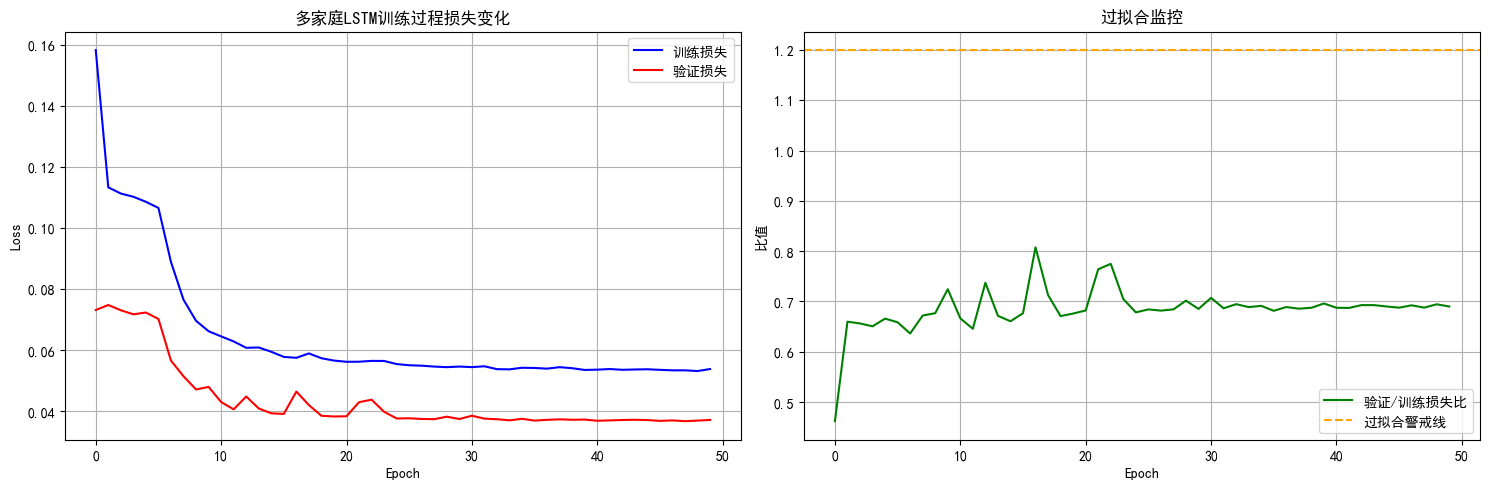


=== 多家庭LSTM训练总结 ===
最终训练损失: 0.053756
最终验证损失: 0.037089
最佳验证损失: 0.036676
过拟合程度: 0.69 (正常)
模型已保存为: best_model_multihousehold.pth


In [6]:
# 训练循环
num_epochs = 50  
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0
patience = 10

print(f"\n开始训练多家庭LSTM模型...")
print(f"训练集样本数: {len(train_dataset)}")
print(f"验证集样本数: {len(val_dataset)}")

for epoch in range(num_epochs):
    # ============ 训练阶段 ============
    model.train()
    train_loss = 0
    train_batches = 0
    
    # 训练进度条
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', 
                      ncols=100, leave=False)
    for x, household_ids, y in train_pbar:
        x = x.to(device, non_blocking=True)
        household_ids = household_ids.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        y_pred = model(x, household_ids).squeeze()
        loss = loss_fn(y_pred, y)
        loss.backward()
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        train_batches += 1
        
        # 更新进度条显示当前loss
        train_pbar.set_postfix({'Loss': f'{loss.item():.6f}'})
    
    avg_train_loss = train_loss / train_batches
    
    # ============ 验证阶段 ============
    model.eval()
    val_loss = 0
    val_batches = 0
    
    # 验证进度条
    val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', 
                    ncols=100, leave=False)
    with torch.no_grad():
        for x, household_ids, y in val_pbar:
            x = x.to(device, non_blocking=True)
            household_ids = household_ids.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            
            y_pred = model(x, household_ids).squeeze()
            loss = loss_fn(y_pred, y)
            val_loss += loss.item()
            val_batches += 1
            
            # 更新验证进度条
            val_pbar.set_postfix({'Loss': f'{loss.item():.6f}'})
    
    avg_val_loss = val_loss / val_batches
    
    # 学习率调度
    scheduler.step(avg_val_loss)
    # 记录损失
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # 早停检查
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # 保存最佳模型
        torch.save(model.state_dict(), 'best_model_multihousehold.pth')
        best_epoch = epoch + 1
    else:
        patience_counter += 1
    
    # 显示epoch结果
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {current_lr:.6f}')
    
    # 早停
    if patience_counter >= patience:
        print(f"早停于epoch {epoch+1}，最佳模型在epoch {best_epoch}")
        break

print(f"\n训练完成！")
print(f"最佳验证损失: {best_val_loss:.6f} (epoch {best_epoch})")

# 加载最佳模型
if best_epoch > 0:
    model.load_state_dict(torch.load('best_model_multihousehold.pth'))

# 可视化训练过程
plt.figure(figsize=(15, 5))
# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='训练损失', color='blue')
plt.plot(val_losses, label='验证损失', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('多家庭LSTM训练过程损失变化')
plt.legend()
plt.grid(True)
# 过拟合分析
plt.subplot(1, 2, 2)
overfitting_ratio = [v/t if t > 0 else 1 for t, v in zip(train_losses, val_losses)]
plt.plot(overfitting_ratio, label='验证/训练损失比', color='green')
plt.axhline(y=1.2, color='orange', linestyle='--', label='过拟合警戒线')
plt.xlabel('Epoch')
plt.ylabel('比值')
plt.title('过拟合监控')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 性能总结
print("\n=== 多家庭LSTM训练总结 ===")
print(f"最终训练损失: {train_losses[-1]:.6f}")
print(f"最终验证损失: {val_losses[-1]:.6f}")
print(f"最佳验证损失: {best_val_loss:.6f}")
print(f"过拟合程度: {val_losses[-1]/train_losses[-1]:.2f} ({'正常' if val_losses[-1]/train_losses[-1] < 1.5 else '可能过拟合'})")
print(f"模型已保存为: best_model_multihousehold.pth")

加载已训练的多家庭LSTM模型...
模型加载成功！
正在收集验证集预测结果...
模型加载成功！
正在收集验证集预测结果...
按家庭分别进行反归一化...
家庭 3039 (编码0): 1728 个样本反归一化完成
家庭 3538 (编码1): 1728 个样本反归一化完成
家庭 4031 (编码2): 1728 个样本反归一化完成
家庭 6139 (编码3): 1728 个样本反归一化完成
家庭 661 (编码4): 1728 个样本反归一化完成
家庭 7951 (编码5): 1728 个样本反归一化完成
家庭 8386 (编码6): 1728 个样本反归一化完成
家庭 8565 (编码7): 1728 个样本反归一化完成
家庭 9278 (编码8): 1728 个样本反归一化完成
家庭 9922 (编码9): 1728 个样本反归一化完成
共 17280 个预测样本
10 个不同家庭
按家庭分别进行反归一化...
家庭 3039 (编码0): 1728 个样本反归一化完成
家庭 3538 (编码1): 1728 个样本反归一化完成
家庭 4031 (编码2): 1728 个样本反归一化完成
家庭 6139 (编码3): 1728 个样本反归一化完成
家庭 661 (编码4): 1728 个样本反归一化完成
家庭 7951 (编码5): 1728 个样本反归一化完成
家庭 8386 (编码6): 1728 个样本反归一化完成
家庭 8565 (编码7): 1728 个样本反归一化完成
家庭 9278 (编码8): 1728 个样本反归一化完成
家庭 9922 (编码9): 1728 个样本反归一化完成
共 17280 个预测样本
10 个不同家庭


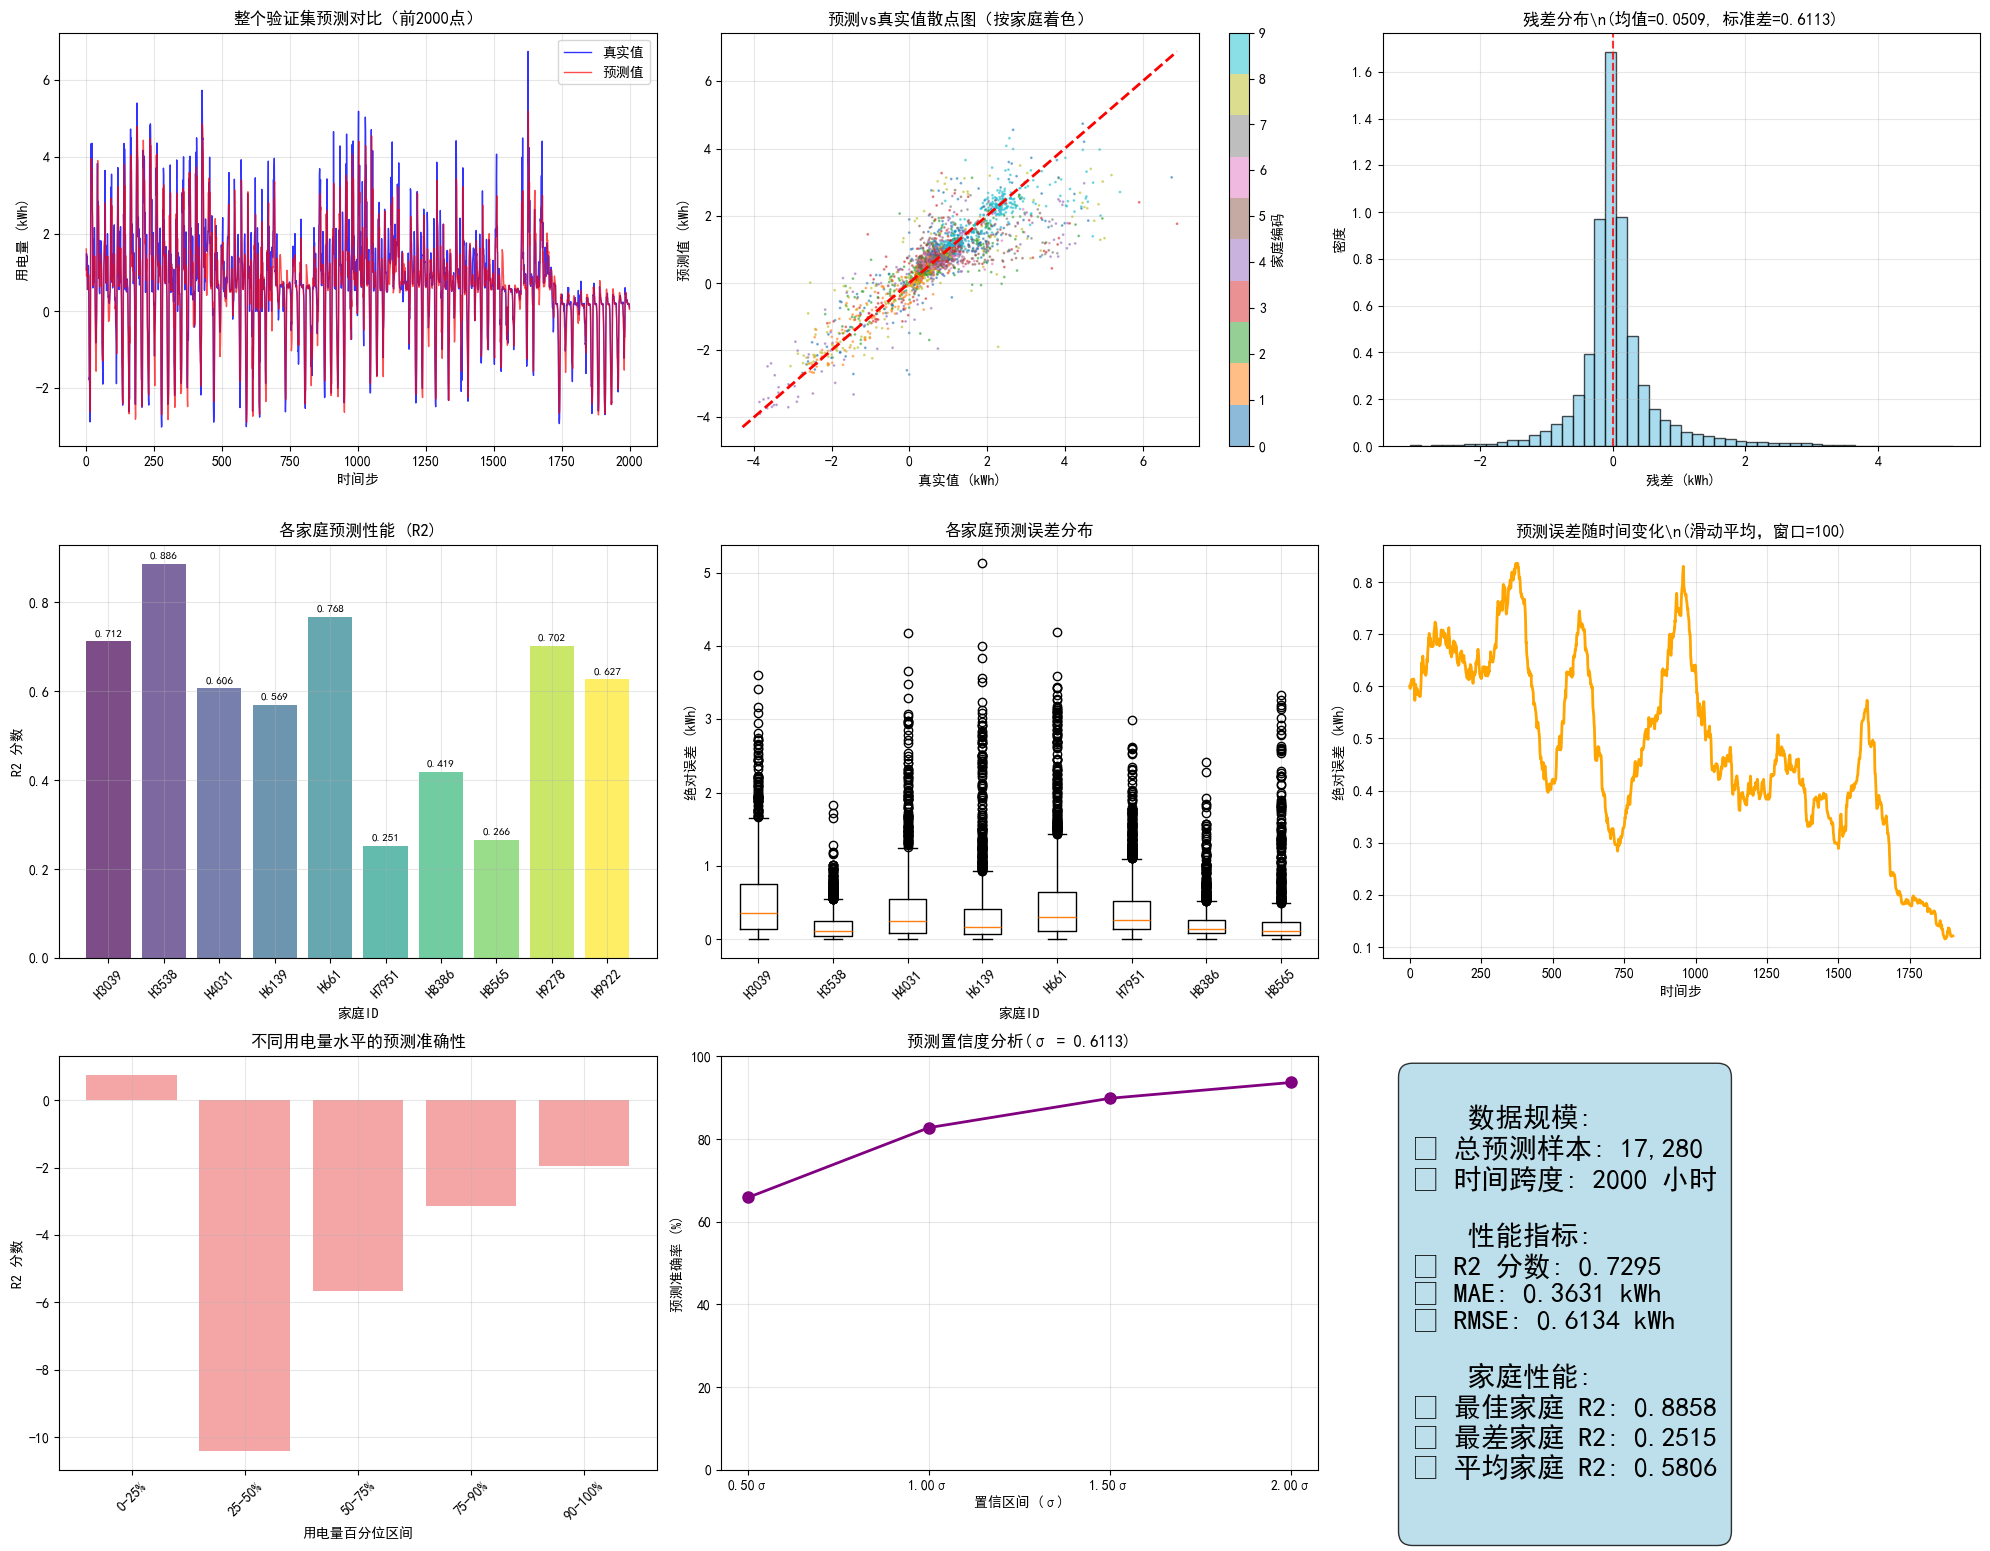

\n=== 详细家庭级别分析 ===


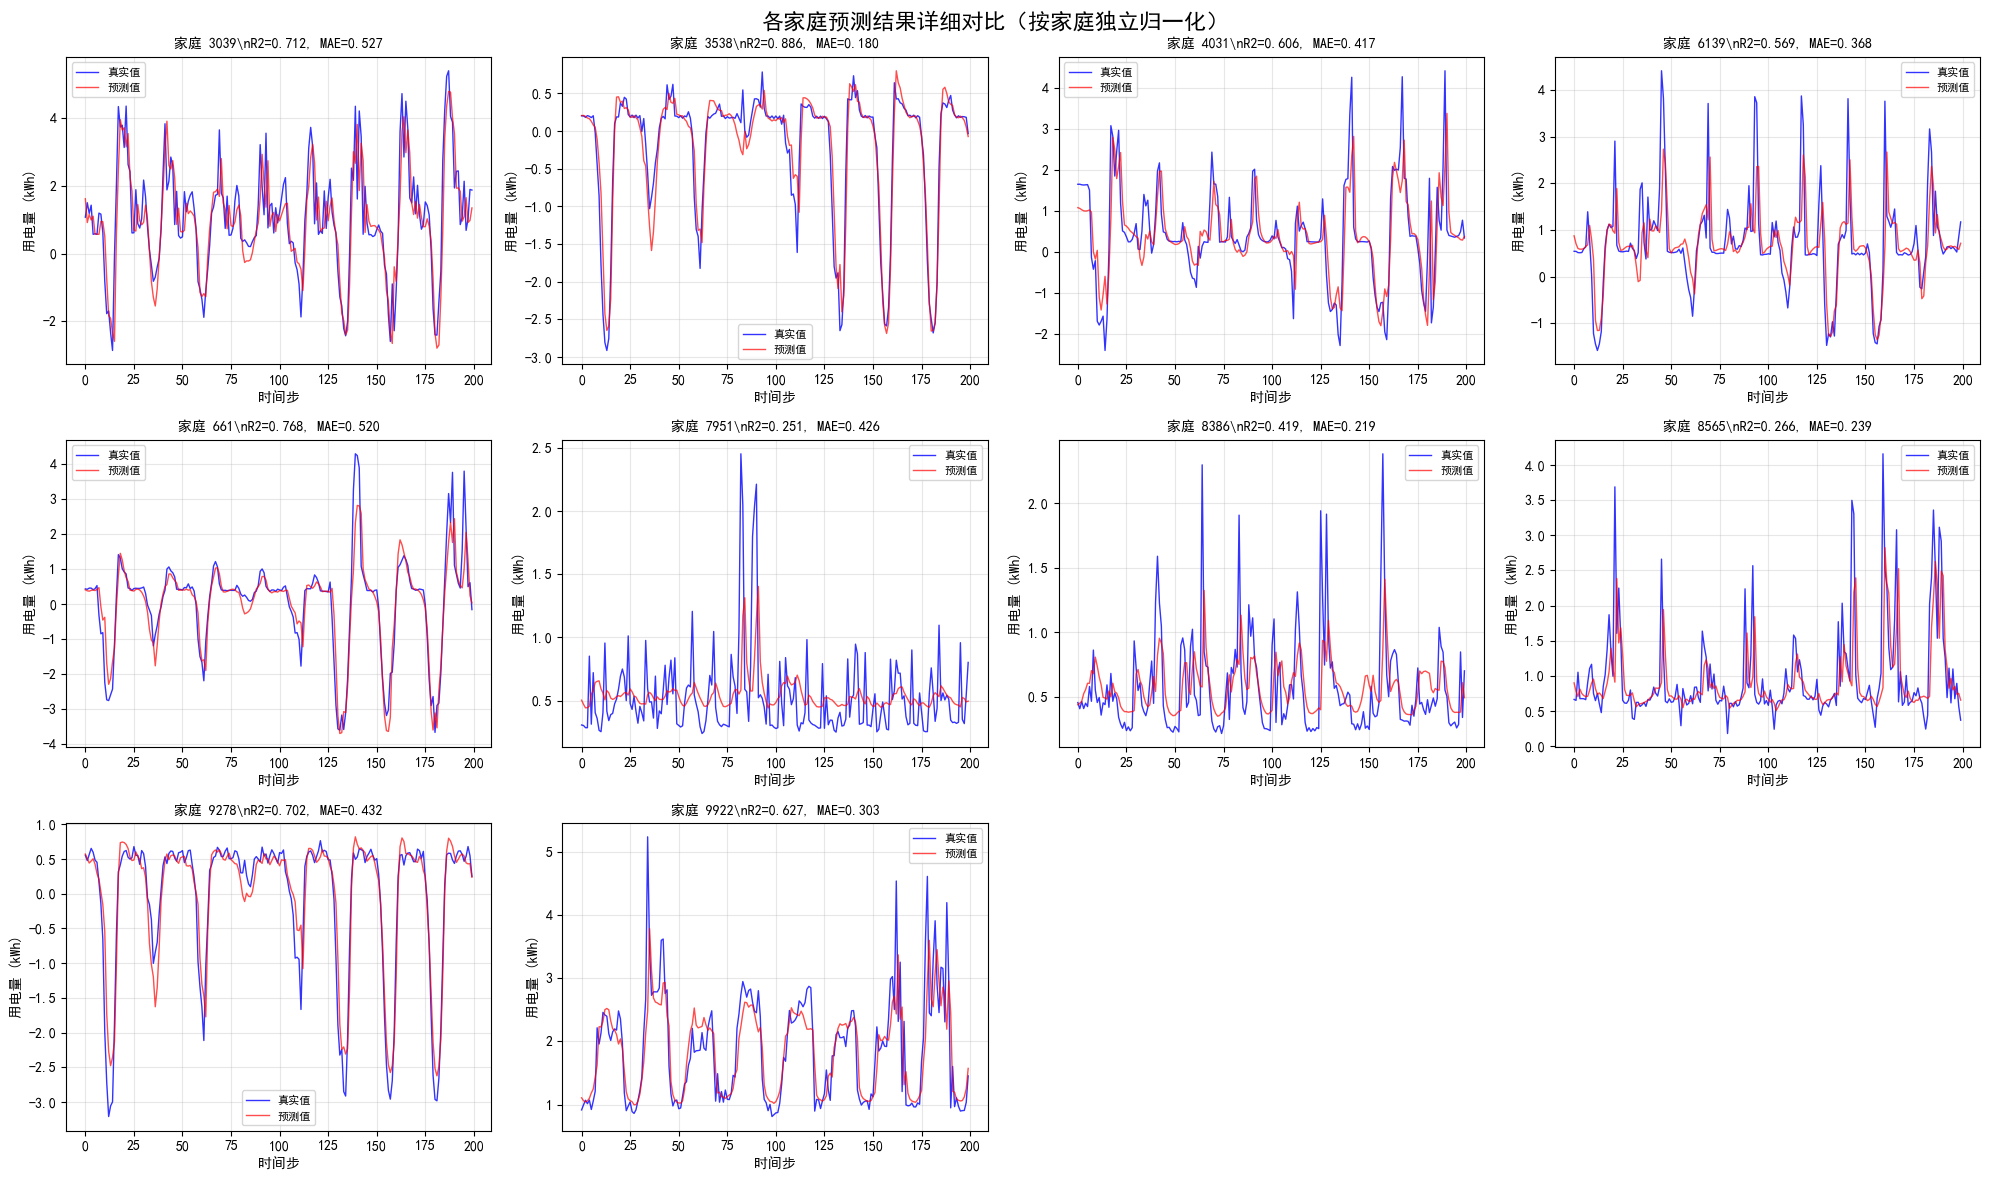

\n=== 详细数值分析报告（按家庭独立归一化）===
家庭ID     样本数      R2分数       MAE        RMSE       平均用电       用电范围           
-------------------------------------------------------------------------------------
3039     1728     0.7121     0.5274     0.7507     0.8844     -3.00-6.75     
3538     1728     0.8858     0.1802     0.2790     -0.1208    -2.95-1.60     
4031     1728     0.6061     0.4167     0.6600     0.4577     -2.41-4.97     
6139     1728     0.5689     0.3681     0.6618     0.7072     -2.11-6.89     
661      1728     0.7678     0.5200     0.8206     0.3323     -4.29-6.18     
7951     1728     0.2515     0.4261     0.6169     0.8936     0.00-3.87      
8386     1728     0.4190     0.2186     0.3336     0.6495     0.00-3.61      
8565     1728     0.2659     0.2394     0.4812     0.8660     -0.00-4.40     
9278     1728     0.7021     0.4315     0.7658     0.4524     -3.21-5.30     
9922     1728     0.6268     0.3035     0.5145     1.9367     0.00-6.10      
\n=== 总体统计 ===
总体 R2 分数: 0.7

In [7]:
# 对整个验证集进行全面预测分析和可视化
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from collections import defaultdict
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']        # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False          # 关键：修复负号显示问题
plt.rcParams['figure.dpi'] = 100                    # 设置图片清晰度
plt.rcParams['savefig.dpi'] = 100                   # 设置保存图片的清晰度

# 确保模型已加载
if os.path.exists('best_model_multihousehold.pth'):
    print("加载已训练的多家庭LSTM模型...")
    model.load_state_dict(torch.load('best_model_multihousehold.pth'))
    model.eval()
    print("模型加载成功！")
else:
    print("未找到训练好的模型文件，需要先运行训练代码")

# 确保模型处于评估模式
model.eval()

# 重新收集验证集的所有预测结果，这次包含更多信息
all_predictions = []
all_targets = []
all_household_ids = []
all_sequences = []  # 存储输入序列

print("正在收集验证集预测结果...")
with torch.no_grad():
    for batch_idx, (x, household_ids, y) in enumerate(val_loader):
        x = x.to(device)
        household_ids = household_ids.to(device)
        
        # 获取预测
        y_pred = model(x, household_ids).squeeze()
        
        # 转换到CPU并存储
        all_predictions.extend(y_pred.cpu().numpy())
        all_targets.extend(y.numpy())
        all_household_ids.extend(household_ids.cpu().numpy())
        all_sequences.extend(x.cpu().numpy())

# 转换为numpy数组
all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)
all_household_ids = np.array(all_household_ids)
all_sequences = np.array(all_sequences)

# 按家庭分别反归一化到原始尺度
print("按家庭分别进行反归一化...")
predictions_original = np.zeros_like(all_predictions)
targets_original = np.zeros_like(all_targets)

# 创建家庭ID到原始ID的映射
household_id_mapping = {code: household_id for code, household_id in enumerate(valid_households)}

for household_code in np.unique(all_household_ids):
    # 获取该家庭的掩码
    mask = all_household_ids == household_code
    
    # 获取原始家庭ID
    original_household_id = household_id_mapping[household_code]
    
    # 获取该家庭的归一化器
    scaler = household_scalers[original_household_id]
    
    # 反归一化该家庭的预测值和真实值
    h_preds = all_predictions[mask].reshape(-1, 1)
    h_targets = all_targets[mask].reshape(-1, 1)
    
    predictions_original[mask] = scaler.inverse_transform(h_preds).flatten()
    targets_original[mask] = scaler.inverse_transform(h_targets).flatten()
    
    print(f"家庭 {original_household_id} (编码{household_code}): {np.sum(mask)} 个样本反归一化完成")

print(f"共 {len(predictions_original)} 个预测样本")
print(f"{len(np.unique(all_household_ids))} 个不同家庭")

# 1. 创建综合可视化图表
plt.figure(figsize=(20, 16))

# 1.1 整体预测vs真实值时序图（显示前2000个点）
plt.subplot(3, 3, 1)
display_points = min(2000, len(predictions_original))
time_indices = np.arange(display_points)
plt.plot(time_indices, targets_original[:display_points], 
            label='真实值', color='blue', alpha=0.8, linewidth=1)
plt.plot(time_indices, predictions_original[:display_points], 
            label='预测值', color='red', alpha=0.7, linewidth=1)
plt.xlabel('时间步')
plt.ylabel('用电量 (kWh)')
plt.title(f'整个验证集预测对比（前{display_points}点）')
plt.legend()
plt.grid(True, alpha=0.3)

# 1.2 预测vs真实值散点图
plt.subplot(3, 3, 2)
sample_indices = np.random.choice(len(predictions_original), 
                                    min(3000, len(predictions_original)), replace=False)
plt.scatter(targets_original[sample_indices], predictions_original[sample_indices], 
            alpha=0.5, s=1, c=all_household_ids[sample_indices], cmap='tab10')
plt.plot([targets_original.min(), targets_original.max()], 
            [targets_original.min(), targets_original.max()], 'r--', lw=2)
plt.xlabel('真实值 (kWh)')
plt.ylabel('预测值 (kWh)')
plt.title('预测vs真实值散点图（按家庭着色）')
plt.colorbar(label='家庭编码')
plt.grid(True, alpha=0.3)

# 1.3 残差分布
plt.subplot(3, 3, 3)
residuals = targets_original - predictions_original
plt.hist(residuals, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.8)
plt.xlabel('残差 (kWh)')
plt.ylabel('密度')
plt.title(f'残差分布\\n(均值={np.mean(residuals):.4f}, 标准差={np.std(residuals):.4f})')
plt.grid(True, alpha=0.3)

# 1.4 按家庭分组的预测性能
plt.subplot(3, 3, 4)
unique_household_codes = np.unique(all_household_ids)
household_performance = {}

for household_code in unique_household_codes:
    mask = all_household_ids == household_code
    if np.sum(mask) > 10:  # 确保有足够样本
        h_targets = targets_original[mask]
        h_preds = predictions_original[mask]
        h_r2 = r2_score(h_targets, h_preds)
        h_mae = mean_absolute_error(h_targets, h_preds)
        
        # 获取原始家庭ID
        original_household_id = household_id_mapping[household_code]
        household_performance[original_household_id] = {
            'r2': h_r2, 'mae': h_mae, 'count': len(h_targets), 'code': household_code
        }

household_ids = list(household_performance.keys())
r2_scores = [household_performance[hid]['r2'] for hid in household_ids]

bars = plt.bar(range(len(household_ids)), r2_scores, 
                color=plt.cm.viridis(np.linspace(0, 1, len(household_ids))), alpha=0.7)
plt.xlabel('家庭ID')
plt.ylabel('R2 分数')
plt.title('各家庭预测性能 (R2)')
plt.xticks(range(len(household_ids)), [f'H{hid}' for hid in household_ids], rotation=45)
plt.grid(True, alpha=0.3)

# 添加数值标签
for i, (bar, score) in enumerate(zip(bars, r2_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{score:.3f}', ha='center', va='bottom', fontsize=8)

# 1.5 误差分布箱线图（按家庭）
plt.subplot(3, 3, 5)
household_errors = []
household_labels = []

for hid in household_ids[:8]:  # 只显示前8个家庭避免图表过于拥挤
    household_code = household_performance[hid]['code']
    mask = all_household_ids == household_code
    if np.sum(mask) > 10:
        errors = np.abs(targets_original[mask] - predictions_original[mask])
        household_errors.append(errors)
        household_labels.append(f'H{hid}')

plt.boxplot(household_errors, labels=household_labels)
plt.ylabel('绝对误差 (kWh)')
plt.xlabel('家庭ID')
plt.title('各家庭预测误差分布')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 1.6 预测误差随时间变化
plt.subplot(3, 3, 6)
abs_errors = np.abs(residuals)
# 计算滑动平均来平滑误差曲线
window_size = 100
if len(abs_errors) > window_size:
    smoothed_errors = np.convolve(abs_errors, np.ones(window_size)/window_size, mode='valid')
    plt.plot(smoothed_errors[:display_points-window_size+1], color='orange', linewidth=2)
    plt.xlabel('时间步')
    plt.ylabel('绝对误差 (kWh)')
    plt.title(f'预测误差随时间变化\\n(滑动平均，窗口={window_size})')
    plt.grid(True, alpha=0.3)

# 1.7 不同用电量水平的预测准确性
plt.subplot(3, 3, 7)
# 将真实值分为不同区间
percentiles = [0, 25, 50, 75, 90, 100]
quantiles = np.percentile(targets_original, percentiles)

interval_r2 = []
interval_labels = []

for i in range(len(quantiles)-1):
    mask = (targets_original >= quantiles[i]) & (targets_original < quantiles[i+1])
    if np.sum(mask) > 10:
        interval_targets = targets_original[mask]
        interval_preds = predictions_original[mask]
        interval_r2.append(r2_score(interval_targets, interval_preds))
        interval_labels.append(f'{percentiles[i]}-{percentiles[i+1]}%')

plt.bar(range(len(interval_r2)), interval_r2, color='lightcoral', alpha=0.7)
plt.xlabel('用电量百分位区间')
plt.ylabel('R2 分数')
plt.title('不同用电量水平的预测准确性')
plt.xticks(range(len(interval_labels)), interval_labels, rotation=45)
plt.grid(True, alpha=0.3)

# 1.8 模型预测置信度分析
plt.subplot(3, 3, 8)
# 计算预测的标准差作为不确定性度量
prediction_std = np.std(predictions_original)
residual_std = np.std(residuals)
confidence_intervals = [residual_std * i for i in [0.5, 1.0, 1.5, 2.0]]

accuracy_within_ci = []
for ci in confidence_intervals:
    within_ci = np.sum(np.abs(residuals) <= ci) / len(residuals) * 100
    accuracy_within_ci.append(within_ci)

plt.plot([f'{ci:.2f}σ' for ci in [0.5, 1.0, 1.5, 2.0]], accuracy_within_ci, 
            marker='o', linewidth=2, markersize=8, color='purple')
plt.xlabel('置信区间 (σ)')
plt.ylabel('预测准确率 (%)')
plt.title(f'预测置信度分析(σ = {residual_std:.4f})')
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

# 1.9 整体性能总结
plt.subplot(3, 3, 9)
plt.axis('off')

# 计算整体指标
overall_r2 = r2_score(targets_original, predictions_original)
overall_mae = mean_absolute_error(targets_original, predictions_original)
overall_mse = mean_squared_error(targets_original, predictions_original)
overall_rmse = np.sqrt(overall_mse)

# 创建性能总结文本
summary_text = f"""
    数据规模:
• 总预测样本: {len(predictions_original):,}
• 时间跨度: {display_points} 小时

    性能指标:
• R2 分数: {overall_r2:.4f}
• MAE: {overall_mae:.4f} kWh
• RMSE: {overall_rmse:.4f} kWh

    家庭性能:
• 最佳家庭 R2: {max(r2_scores):.4f}
• 最差家庭 R2: {min(r2_scores):.4f}
• 平均家庭 R2: {np.mean(r2_scores):.4f}

"""

plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
            fontsize=20, verticalalignment='top', 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

# 2. 创建详细的家庭级别分析
print("\\n=== 详细家庭级别分析 ===")

plt.figure(figsize=(20, 12))

# 为每个家庭创建子图（最多显示12个家庭）
max_households_to_show = min(12, len(household_ids))
cols = 4
rows = (max_households_to_show + cols - 1) // cols

for i, hid in enumerate(household_ids[:max_households_to_show]):
    plt.subplot(rows, cols, i+1)
    
    # 获取该家庭的数据
    household_code = household_performance[hid]['code']
    mask = all_household_ids == household_code
    h_targets = targets_original[mask]
    h_preds = predictions_original[mask]
    
    # 只显示前200个点避免图表过于密集
    display_len = min(200, len(h_targets))
    
    plt.plot(h_targets[:display_len], label='真实值', color='blue', alpha=0.8, linewidth=1)
    plt.plot(h_preds[:display_len], label='预测值', color='red', alpha=0.7, linewidth=1)
    
    # 计算该家庭的性能指标
    h_r2 = r2_score(h_targets, h_preds)
    h_mae = mean_absolute_error(h_targets, h_preds)
    
    plt.title(f'家庭 {hid}\\nR2={h_r2:.3f}, MAE={h_mae:.3f}', fontsize=10)
    plt.xlabel('时间步')
    plt.ylabel('用电量 (kWh)')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

plt.suptitle('各家庭预测结果详细对比（按家庭独立归一化）', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# 3. 生成详细的数值报告
print("\\n=== 详细数值分析报告（按家庭独立归一化）===")
print(f"{'家庭ID':<8} {'样本数':<8} {'R2分数':<10} {'MAE':<10} {'RMSE':<10} {'平均用电':<10} {'用电范围':<15}")
print("-" * 85)

for hid in sorted(household_ids):
    household_code = household_performance[hid]['code']
    mask = all_household_ids == household_code
    h_targets = targets_original[mask]
    h_preds = predictions_original[mask]
    
    h_r2 = r2_score(h_targets, h_preds)
    h_mae = mean_absolute_error(h_targets, h_preds)
    h_rmse = np.sqrt(mean_squared_error(h_targets, h_preds))
    h_mean_consumption = np.mean(h_targets)
    h_range = f"{h_targets.min():.2f}-{h_targets.max():.2f}"
    
    print(f"{hid:<8} {len(h_targets):<8} {h_r2:<10.4f} {h_mae:<10.4f} {h_rmse:<10.4f} {h_mean_consumption:<10.4f} {h_range:<15}")

print("\\n=== 总体统计 ===")
print(f"总体 R2 分数: {overall_r2:.6f}")
print(f"总体 MAE: {overall_mae:.6f} kWh")
print(f"总体 RMSE: {overall_rmse:.6f} kWh")
print(f"预测值范围: {predictions_original.min():.4f} - {predictions_original.max():.4f} kWh")
print(f"真实值范围: {targets_original.min():.4f} - {targets_original.max():.4f} kWh")
print(f"残差范围: {residuals.min():.4f} - {residuals.max():.4f} kWh")

print("\\n=== 各家庭归一化器信息 ===")
for household_id in valid_households:
    scaler = household_scalers[household_id]
    data_min = scaler.data_min_[0]
    data_max = scaler.data_max_[0]
    data_range = scaler.data_range_[0]
    print(f"家庭 {household_id}: 最小值={data_min:.4f}, 最大值={data_max:.4f}, 范围={data_range:.4f}")

#GRU

In [8]:
# 多家庭GRU模型训练与评估
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MultiHouseholdGRUModel(nn.Module):
    def __init__(self, num_households, input_size=1, hidden_size=128, embedding_dim=32, num_layers=3, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding_dim = embedding_dim
        self.household_embedding = nn.Embedding(num_households, embedding_dim)
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fusion_layer = nn.Linear(hidden_size + embedding_dim, hidden_size)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x, household_ids):
        x = x.unsqueeze(-1)
        gru_out, _ = self.gru(x)
        gru_out = gru_out[:, -1, :]
        household_emb = self.household_embedding(household_ids)
        combined = torch.cat([gru_out, household_emb], dim=1)
        fused = self.relu(self.fusion_layer(combined))
        out = self.dropout(fused)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

gru_model = MultiHouseholdGRUModel(
    num_households=num_unique_households,
    input_size=1,
    hidden_size=128,
    embedding_dim=32,
    num_layers=3,
    dropout=0.2
).to(device)

gru_total_params = sum(p.numel() for p in gru_model.parameters())
print(f'多家庭GRU模型参数量: {gru_total_params:,}')

gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001, weight_decay=1e-5)
gru_loss_fn = nn.MSELoss()
gru_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(gru_optimizer, 'min', patience=3, factor=0.5)

gru_num_epochs = 50
gru_patience = 10
gru_best_val_loss = float('inf')
gru_patience_counter = 0
gru_best_epoch = 0
gru_best_model_path = 'best_model_multihousehold_gru.pth'
gru_train_losses = []
gru_val_losses = []

print('\n开始训练多家庭GRU模型...')
print(f'训练集样本数: {len(train_dataset)}')
print(f'验证集样本数: {len(val_dataset)}')

for epoch in range(gru_num_epochs):
    gru_model.train()
    epoch_train_loss = 0.0
    train_batches = 0
    train_pbar = tqdm(train_loader, desc=f'GRU Epoch {epoch + 1}/{gru_num_epochs} [Train]', ncols=100, leave=False)
    for x, household_ids, y in train_pbar:
        x = x.to(device, non_blocking=True)
        household_ids = household_ids.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        gru_optimizer.zero_grad()
        preds = gru_model(x, household_ids).squeeze()
        loss = gru_loss_fn(preds, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_model.parameters(), max_norm=1.0)
        gru_optimizer.step()

        epoch_train_loss += loss.item()
        train_batches += 1
        train_pbar.set_postfix({'Loss': f'{loss.item():.6f}'})

    avg_train_loss = epoch_train_loss / max(train_batches, 1)

    gru_model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    val_pbar = tqdm(val_loader, desc=f'GRU Epoch {epoch + 1}/{gru_num_epochs} [Val]', ncols=100, leave=False)
    with torch.no_grad():
        for x, household_ids, y in val_pbar:
            x = x.to(device, non_blocking=True)
            household_ids = household_ids.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            preds = gru_model(x, household_ids).squeeze()
            loss = gru_loss_fn(preds, y)
            epoch_val_loss += loss.item()
            val_batches += 1
            val_pbar.set_postfix({'Loss': f'{loss.item():.6f}'})

    avg_val_loss = epoch_val_loss / max(val_batches, 1)

    gru_scheduler.step(avg_val_loss)
    gru_train_losses.append(avg_train_loss)
    gru_val_losses.append(avg_val_loss)

    if avg_val_loss < gru_best_val_loss:
        gru_best_val_loss = avg_val_loss
        gru_patience_counter = 0
        gru_best_epoch = epoch + 1
        torch.save(gru_model.state_dict(), gru_best_model_path)
    else:
        gru_patience_counter += 1

    current_lr = gru_optimizer.param_groups[0]['lr']
    print(f'GRU Epoch {epoch + 1}/{gru_num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {current_lr:.6f}')

    if gru_patience_counter >= gru_patience:
        print(f'GRU 早停于 epoch {epoch + 1}，最佳模型在 epoch {gru_best_epoch}')
        break

print('\nGRU 训练完成！')
print(f'最优验证损失: {gru_best_val_loss:.6f} (epoch {gru_best_epoch})')



多家庭GRU模型参数量: 277,697

开始训练多家庭GRU模型...
训练集样本数: 69840
验证集样本数: 17280


GRU Epoch 1/50 | Train Loss: 0.037038 | Val Loss: 0.012287 | LR: 0.001000


GRU Epoch 2/50 | Train Loss: 0.022992 | Val Loss: 0.012027 | LR: 0.001000


GRU Epoch 3/50 | Train Loss: 0.021284 | Val Loss: 0.009915 | LR: 0.001000


GRU Epoch 4/50 | Train Loss: 0.015663 | Val Loss: 0.006465 | LR: 0.001000


...

GRU Epoch 46/50 | Train Loss: 0.006579 | Val Loss: 0.003806 | LR: 0.000250


GRU Epoch 47/50 | Train Loss: 0.006449 | Val Loss: 0.003825 | LR: 0.000250


GRU Epoch 48/50 | Train Loss: 0.006473 | Val Loss: 0.003897 | LR: 0.000250


GRU Epoch 49/50 | Train Loss: 0.006548 | Val Loss: 0.003836 | LR: 0.000250


GRU Epoch 50/50 | Train Loss: 0.006400 | Val Loss: 0.003806 | LR: 0.000250

GRU 训练完成！
最优验证损失: 0.003806 (epoch 50)


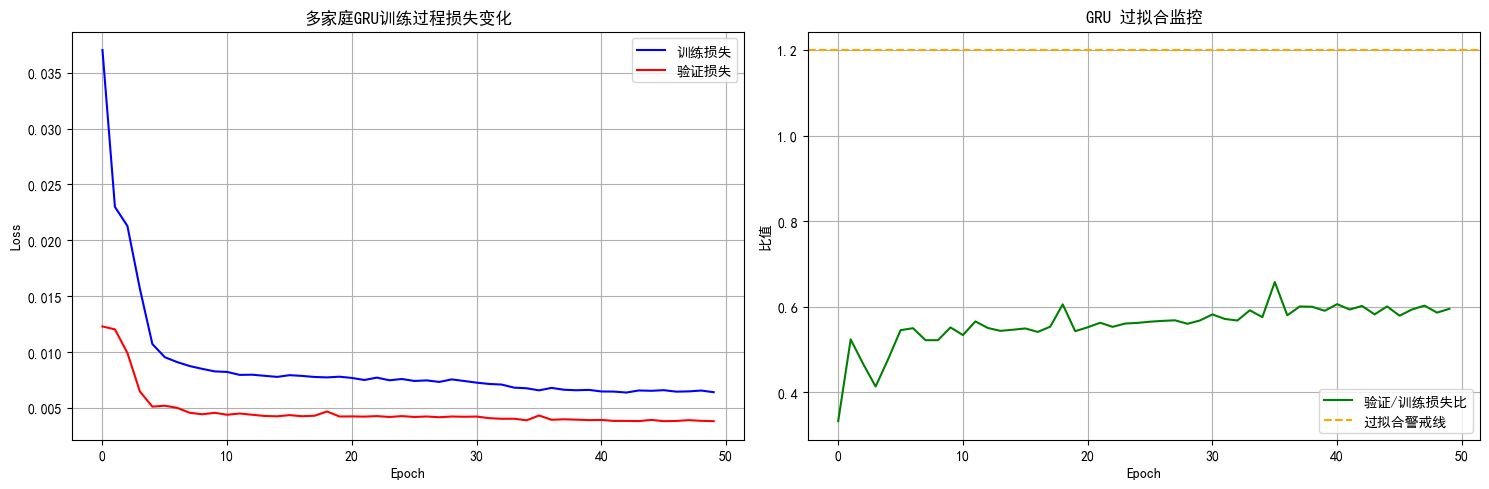


=== 多家庭GRU训练总结 ===
最终训练损失: 0.006400
最终验证损失: 0.003806
最佳验证损失: 0.003806
过拟合程度: 0.59 (正常)
模型已保存为: best_model_multihousehold_gru.pth

加载并评估多家庭GRU模型...
正在收集验证集预测结果 (GRU)...
按家庭分别进行反归一化 (GRU)...
家庭 3039 (编码 0): 1728 个样本反归一化完成
家庭 3538 (编码 1): 1728 个样本反归一化完成
家庭 4031 (编码 2): 1728 个样本反归一化完成
家庭 6139 (编码 3): 1728 个样本反归一化完成
家庭 661 (编码 4): 1728 个样本反归一化完成
家庭 7951 (编码 5): 1728 个样本反归一化完成
家庭 8386 (编码 6): 1728 个样本反归一化完成
家庭 8565 (编码 7): 1728 个样本反归一化完成
家庭 9278 (编码 8): 1728 个样本反归一化完成
家庭 9922 (编码 9): 1728 个样本反归一化完成
共 17280 个预测样本
10 个不同家庭
按家庭分别进行反归一化 (GRU)...
家庭 3039 (编码 0): 1728 个样本反归一化完成
家庭 3538 (编码 1): 1728 个样本反归一化完成
家庭 4031 (编码 2): 1728 个样本反归一化完成
家庭 6139 (编码 3): 1728 个样本反归一化完成
家庭 661 (编码 4): 1728 个样本反归一化完成
家庭 7951 (编码 5): 1728 个样本反归一化完成
家庭 8386 (编码 6): 1728 个样本反归一化完成
家庭 8565 (编码 7): 1728 个样本反归一化完成
家庭 9278 (编码 8): 1728 个样本反归一化完成
家庭 9922 (编码 9): 1728 个样本反归一化完成
共 17280 个预测样本
10 个不同家庭


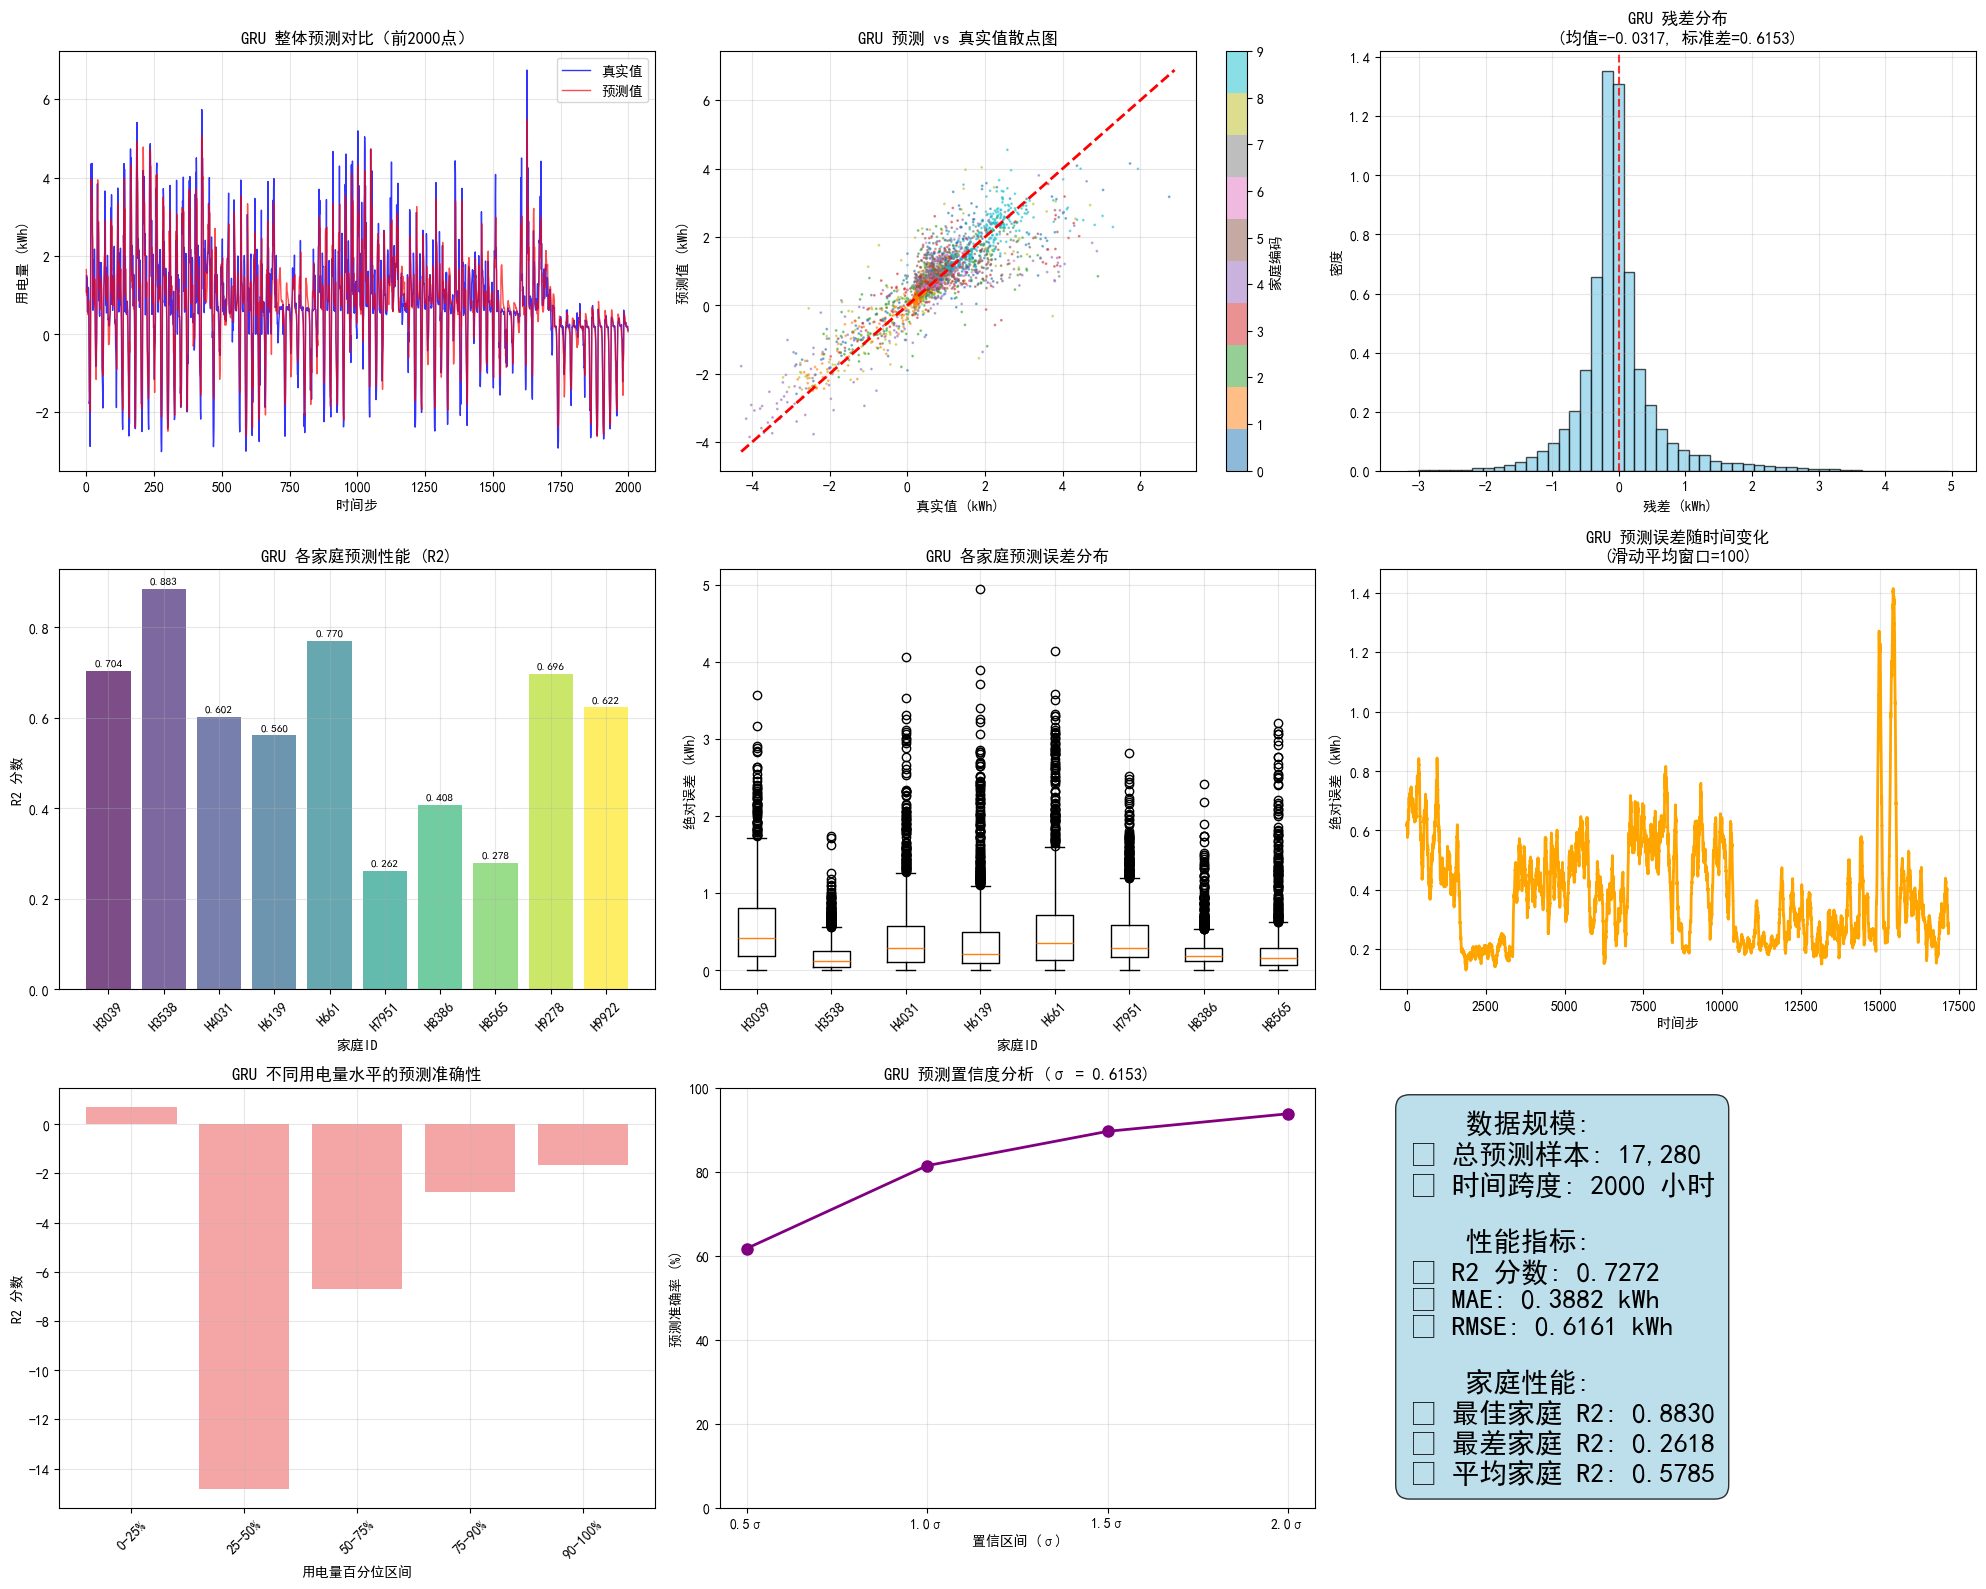


=== 详细家庭级别分析（GRU） ===


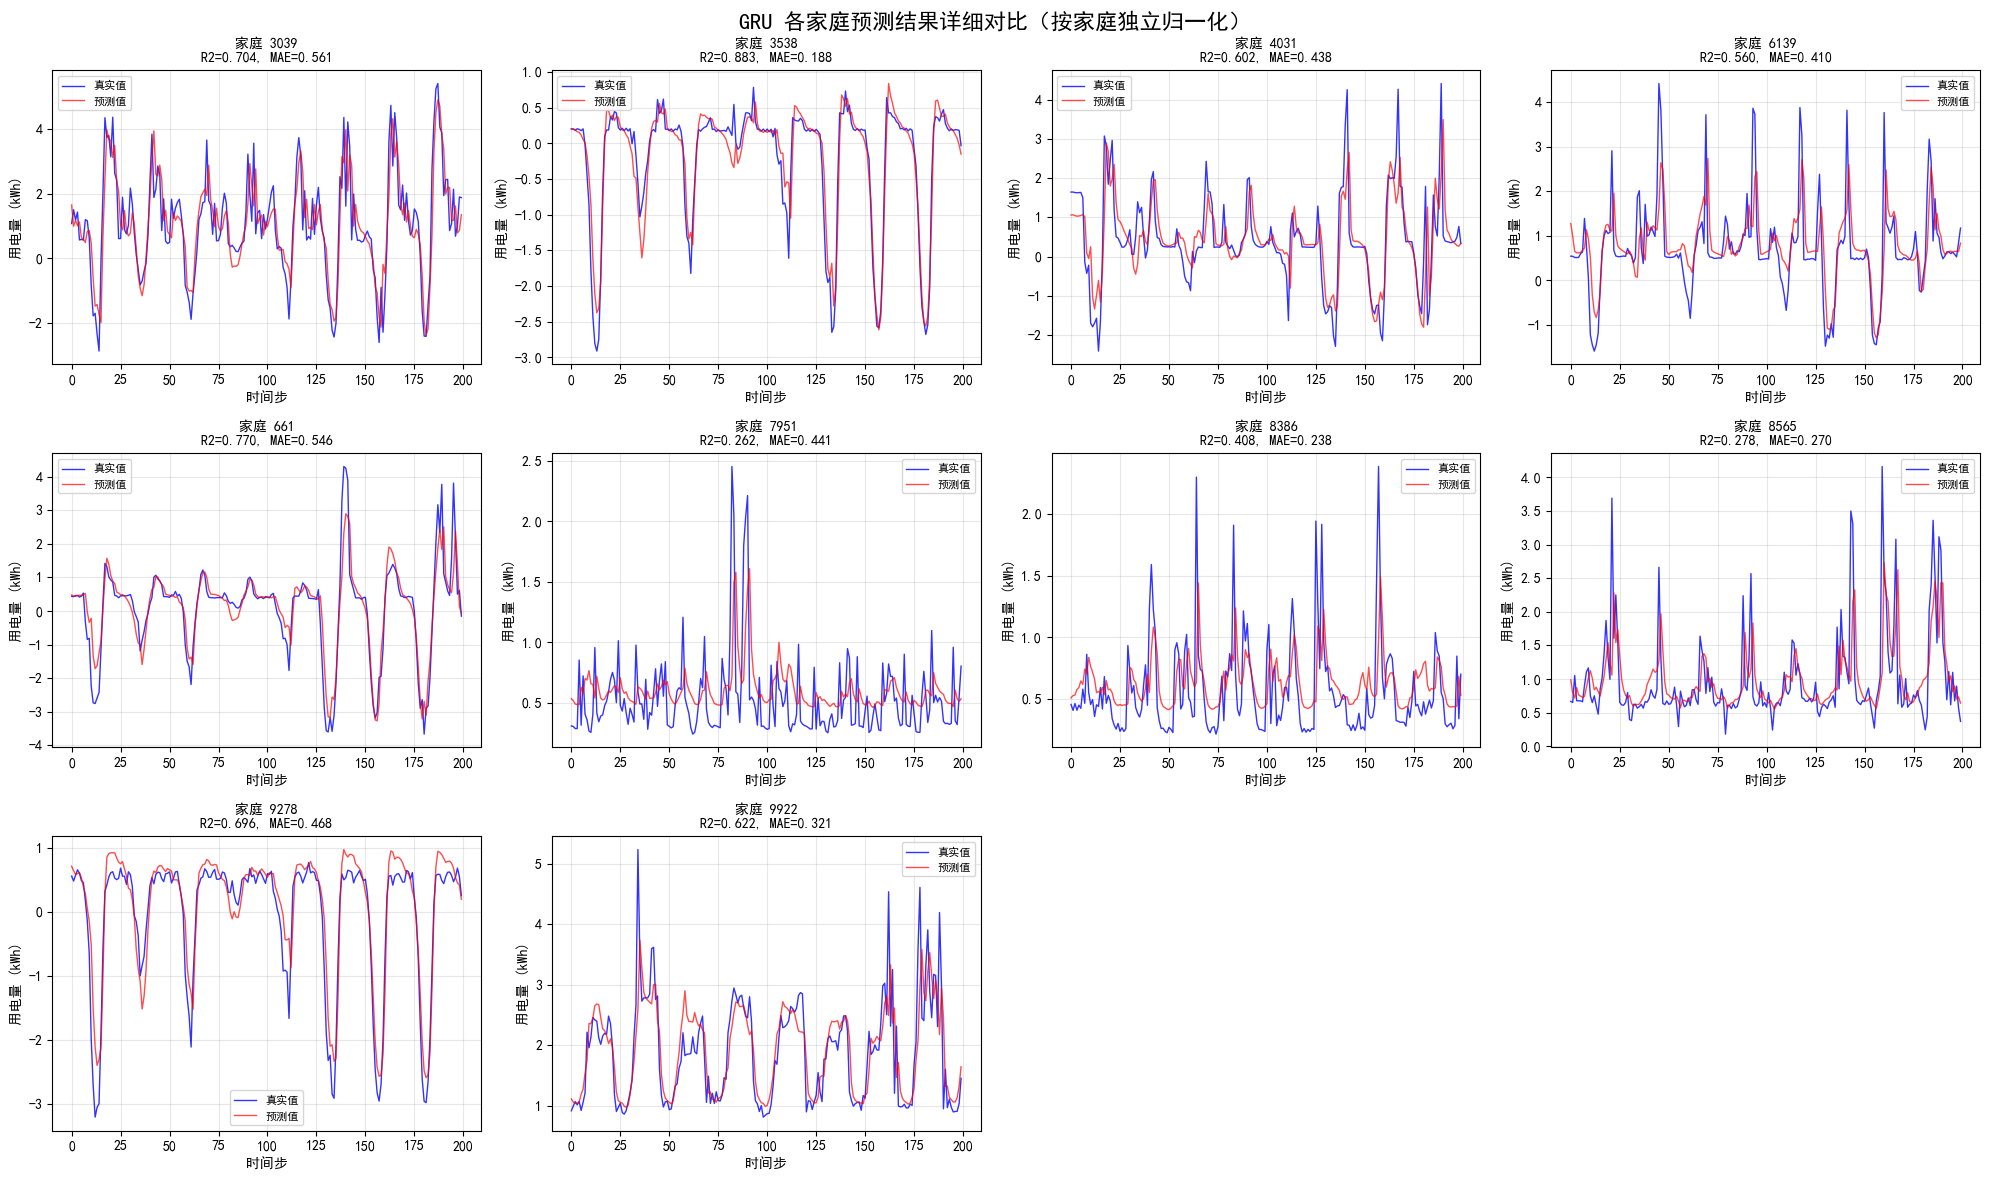


=== 详细数值分析报告（GRU，按家庭独立归一化）===
家庭ID     样本数      R2分数       MAE        RMSE       平均用电       用电范围           
-------------------------------------------------------------------------------------
3039     1728     0.7039     0.5611     0.7614     0.8844     -3.00-6.75     
3538     1728     0.8830     0.1883     0.2823     -0.1208    -2.95-1.60     
4031     1728     0.6019     0.4385     0.6636     0.4577     -2.41-4.97     
6139     1728     0.5604     0.4098     0.6683     0.7072     -2.11-6.89     
661      1728     0.7702     0.5463     0.8164     0.3323     -4.29-6.18     
7951     1728     0.2618     0.4413     0.6127     0.8936     0.00-3.87      
8386     1728     0.4076     0.2383     0.3368     0.6495     0.00-3.61      
8565     1728     0.2782     0.2696     0.4772     0.8660     -0.00-4.40     
9278     1728     0.6957     0.4680     0.7739     0.4524     -3.21-5.30     
9922     1728     0.6223     0.3210     0.5176     1.9367     0.00-6.10      

=== GRU 总体统计 ===
总体 R2 分

In [9]:
if os.path.exists(gru_best_model_path):
    gru_model.load_state_dict(torch.load(gru_best_model_path))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(gru_train_losses, label='训练损失', color='blue')
plt.plot(gru_val_losses, label='验证损失', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('多家庭GRU训练过程损失变化')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
gru_overfitting_ratio = [v / t if t > 0 else 1 for t, v in zip(gru_train_losses, gru_val_losses)]
plt.plot(gru_overfitting_ratio, label='验证/训练损失比', color='green')
plt.axhline(y=1.2, color='orange', linestyle='--', label='过拟合警戒线')
plt.xlabel('Epoch')
plt.ylabel('比值')
plt.title('GRU 过拟合监控')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('\n=== 多家庭GRU训练总结 ===')
print(f'最终训练损失: {gru_train_losses[-1]:.6f}')
print(f'最终验证损失: {gru_val_losses[-1]:.6f}')
print(f'最佳验证损失: {gru_best_val_loss:.6f}')
overfit_ratio = gru_val_losses[-1] / gru_train_losses[-1]
overfit_status = '正常' if overfit_ratio < 1.5 else '可能过拟合'
print(f'过拟合程度: {overfit_ratio:.2f} ({overfit_status})')
print(f'模型已保存为: {gru_best_model_path}')

gru_model.eval()

print('\n加载并评估多家庭GRU模型...')
print('正在收集验证集预测结果 (GRU)...')
gru_predictions = []
gru_targets = []
gru_household_ids = []
gru_sequences = []

with torch.no_grad():
    for batch_idx, (x, household_ids, y) in enumerate(val_loader):
        x = x.to(device)
        household_ids = household_ids.to(device)
        preds = gru_model(x, household_ids).squeeze()
        gru_predictions.extend(preds.cpu().numpy())
        gru_targets.extend(y.numpy())
        gru_household_ids.extend(household_ids.cpu().numpy())
        gru_sequences.extend(x.cpu().numpy())

gru_predictions = np.array(gru_predictions)
gru_targets = np.array(gru_targets)
gru_household_ids = np.array(gru_household_ids)
gru_sequences = np.array(gru_sequences)

print('按家庭分别进行反归一化 (GRU)...')
gru_predictions_original = np.zeros_like(gru_predictions)
gru_targets_original = np.zeros_like(gru_targets)
gru_household_id_mapping = {code: household_id for code, household_id in enumerate(valid_households)}

for household_code in np.unique(gru_household_ids):
    mask = gru_household_ids == household_code
    original_household_id = gru_household_id_mapping[household_code]
    scaler = household_scalers[original_household_id]
    h_preds = gru_predictions[mask].reshape(-1, 1)
    h_targets = gru_targets[mask].reshape(-1, 1)
    gru_predictions_original[mask] = scaler.inverse_transform(h_preds).flatten()
    gru_targets_original[mask] = scaler.inverse_transform(h_targets).flatten()
    print(f'家庭 {original_household_id} (编码 {household_code}): {np.sum(mask)} 个样本反归一化完成')

print(f'共 {len(gru_predictions_original)} 个预测样本')
print(f'{len(np.unique(gru_household_ids))} 个不同家庭')

plt.figure(figsize=(20, 16))

plt.subplot(3, 3, 1)
display_points = min(2000, len(gru_predictions_original))
time_indices = np.arange(display_points)
plt.plot(time_indices, gru_targets_original[:display_points], label='真实值', color='blue', alpha=0.8, linewidth=1)
plt.plot(time_indices, gru_predictions_original[:display_points], label='预测值', color='red', alpha=0.7, linewidth=1)
plt.xlabel('时间步')
plt.ylabel('用电量 (kWh)')
plt.title(f'GRU 整体预测对比（前{display_points}点）')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 2)
if len(gru_predictions_original) > 0:
    sample_size = min(3000, len(gru_predictions_original))
    sample_indices = np.random.choice(len(gru_predictions_original), sample_size, replace=False)
    scatter = plt.scatter(gru_targets_original[sample_indices], gru_predictions_original[sample_indices],
                          alpha=0.5, s=1, c=gru_household_ids[sample_indices], cmap='tab10')
    plt.plot([gru_targets_original.min(), gru_targets_original.max()],
             [gru_targets_original.min(), gru_targets_original.max()], 'r--', lw=2)
    plt.colorbar(scatter, label='家庭编码')
else:
    plt.text(0.5, 0.5, '无数据', ha='center', va='center')
plt.xlabel('真实值 (kWh)')
plt.ylabel('预测值 (kWh)')
plt.title('GRU 预测 vs 真实值散点图')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 3)
gru_residuals = gru_targets_original - gru_predictions_original
plt.hist(gru_residuals, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.8)
plt.xlabel('残差 (kWh)')
plt.ylabel('密度')
plt.title(f'GRU 残差分布\n(均值={np.mean(gru_residuals):.4f}, 标准差={np.std(gru_residuals):.4f})')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 4)
unique_gru_household_codes = np.unique(gru_household_ids)
gru_household_performance = {}
for household_code in unique_gru_household_codes:
    mask = gru_household_ids == household_code
    if np.sum(mask) > 10:
        h_targets = gru_targets_original[mask]
        h_preds = gru_predictions_original[mask]
        h_r2 = r2_score(h_targets, h_preds)
        h_mae = mean_absolute_error(h_targets, h_preds)
        original_household_id = gru_household_id_mapping[household_code]
        gru_household_performance[original_household_id] = {
            'r2': h_r2,
            'mae': h_mae,
            'count': len(h_targets),
            'code': household_code
        }

gru_household_ids_list = list(gru_household_performance.keys())
gru_r2_scores = [gru_household_performance[hid]['r2'] for hid in gru_household_ids_list]

if gru_household_ids_list:
    bars = plt.bar(range(len(gru_household_ids_list)), gru_r2_scores,
                   color=plt.cm.viridis(np.linspace(0, 1, len(gru_household_ids_list))), alpha=0.7)
    plt.xticks(range(len(gru_household_ids_list)), [f'H{hid}' for hid in gru_household_ids_list], rotation=45)
    for bar, score in zip(bars, gru_r2_scores):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{score:.3f}', ha='center', va='bottom', fontsize=8)
else:
    plt.text(0.5, 0.5, '样本数不足', ha='center', va='center', fontsize=12)
plt.xlabel('家庭ID')
plt.ylabel('R2 分数')
plt.title('GRU 各家庭预测性能 (R2)')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 5)
gru_household_errors = []
gru_household_labels = []
for hid in gru_household_ids_list[:8]:
    household_code = gru_household_performance[hid]['code']
    mask = gru_household_ids == household_code
    if np.sum(mask) > 10:
        errors = np.abs(gru_targets_original[mask] - gru_predictions_original[mask])
        gru_household_errors.append(errors)
        gru_household_labels.append(f'H{hid}')
if gru_household_errors:
    plt.boxplot(gru_household_errors, labels=gru_household_labels)
else:
    plt.text(0.5, 0.5, '样本数不足', ha='center', va='center', fontsize=12)
plt.ylabel('绝对误差 (kWh)')
plt.xlabel('家庭ID')
plt.title('GRU 各家庭预测误差分布')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 6)
abs_errors = np.abs(gru_residuals)
window_size = 100
if len(abs_errors) > window_size:
    smoothed_errors = np.convolve(abs_errors, np.ones(window_size) / window_size, mode='valid')
    plt.plot(smoothed_errors[:len(smoothed_errors)], color='orange', linewidth=2)
else:
    plt.plot(abs_errors, color='orange', linewidth=1)
plt.xlabel('时间步')
plt.ylabel('绝对误差 (kWh)')
plt.title(f'GRU 预测误差随时间变化\n(滑动平均窗口={window_size})')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 7)
if len(gru_targets_original) > 0:
    percentiles = [0, 25, 50, 75, 90, 100]
    quantiles = np.percentile(gru_targets_original, percentiles)
    interval_r2 = []
    interval_labels = []
    for idx in range(len(quantiles) - 1):
        mask = (gru_targets_original >= quantiles[idx]) & (gru_targets_original < quantiles[idx + 1])
        if np.sum(mask) > 10:
            interval_targets = gru_targets_original[mask]
            interval_preds = gru_predictions_original[mask]
            interval_r2.append(r2_score(interval_targets, interval_preds))
            interval_labels.append(f'{percentiles[idx]}-{percentiles[idx + 1]}%')
    if interval_r2:
        plt.bar(range(len(interval_r2)), interval_r2, color='lightcoral', alpha=0.7)
        plt.xticks(range(len(interval_labels)), interval_labels, rotation=45)
    else:
        plt.text(0.5, 0.5, '样本数不足', ha='center', va='center', fontsize=12)
else:
    plt.text(0.5, 0.5, '无数据', ha='center', va='center', fontsize=12)
plt.xlabel('用电量百分位区间')
plt.ylabel('R2 分数')
plt.title('GRU 不同用电量水平的预测准确性')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 8)
gru_residual_std = np.std(gru_residuals) if len(gru_residuals) > 0 else 0.0
confidence_sigmas = [0.5, 1.0, 1.5, 2.0]
confidence_intervals = [gru_residual_std * sigma for sigma in confidence_sigmas]
accuracy_within_ci = []
for ci, sigma in zip(confidence_intervals, confidence_sigmas):
    if len(gru_residuals) > 0:
        within_ci = np.sum(np.abs(gru_residuals) <= ci) / len(gru_residuals) * 100
    else:
        within_ci = 0.0
    accuracy_within_ci.append(within_ci)
plt.plot([f'{sigma:.1f}σ' for sigma in confidence_sigmas], accuracy_within_ci,
         marker='o', linewidth=2, markersize=8, color='purple')
plt.xlabel('置信区间 (σ)')
plt.ylabel('预测准确率 (%)')
plt.title(f'GRU 预测置信度分析 (σ = {gru_residual_std:.4f})')
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

plt.subplot(3, 3, 9)
plt.axis('off')
gru_overall_r2 = r2_score(gru_targets_original, gru_predictions_original)
gru_overall_mae = mean_absolute_error(gru_targets_original, gru_predictions_original)
gru_overall_mse = mean_squared_error(gru_targets_original, gru_predictions_original)
gru_overall_rmse = np.sqrt(gru_overall_mse)
if gru_r2_scores:
    gru_best_r2 = max(gru_r2_scores)
    gru_worst_r2 = min(gru_r2_scores)
    gru_mean_r2 = float(np.mean(gru_r2_scores))
else:
    gru_best_r2 = float('nan')
    gru_worst_r2 = float('nan')
    gru_mean_r2 = float('nan')
summary_lines = [
    '    数据规模:',
    f'• 总预测样本: {len(gru_predictions_original):,}',
    f'• 时间跨度: {display_points} 小时',
    '',
    '    性能指标:',
    f'• R2 分数: {gru_overall_r2:.4f}',
    f'• MAE: {gru_overall_mae:.4f} kWh',
    f'• RMSE: {gru_overall_rmse:.4f} kWh',
    '',
    '    家庭性能:',
    f'• 最佳家庭 R2: {gru_best_r2:.4f}',
    f'• 最差家庭 R2: {gru_worst_r2:.4f}',
    f'• 平均家庭 R2: {gru_mean_r2:.4f}'
]
summary_text = '\n'.join(summary_lines)
plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes,
         fontsize=20, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

print('\n=== 详细家庭级别分析（GRU） ===')
if gru_household_ids_list:
    plt.figure(figsize=(20, 12))
    sorted_gru_households = sorted(gru_household_ids_list, key=lambda hid: gru_household_performance[hid]['code'])
    max_households_to_show = min(12, len(sorted_gru_households))
    cols = 4
    rows = (max_households_to_show + cols - 1) // cols if max_households_to_show > 0 else 1
    for idx, hid in enumerate(sorted_gru_households[:max_households_to_show]):
        plt.subplot(rows, cols, idx + 1)
        household_code = gru_household_performance[hid]['code']
        mask = gru_household_ids == household_code
        h_targets = gru_targets_original[mask]
        h_preds = gru_predictions_original[mask]
        display_len = min(200, len(h_targets))
        plt.plot(h_targets[:display_len], label='真实值', color='blue', alpha=0.8, linewidth=1)
        plt.plot(h_preds[:display_len], label='预测值', color='red', alpha=0.7, linewidth=1)
        h_r2 = gru_household_performance[hid]['r2']
        h_mae = gru_household_performance[hid]['mae']
        plt.title(f'家庭 {hid}\nR2={h_r2:.3f}, MAE={h_mae:.3f}', fontsize=10)
        plt.xlabel('时间步')
        plt.ylabel('用电量 (kWh)')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3)
    plt.suptitle('GRU 各家庭预测结果详细对比（按家庭独立归一化）', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print('GRU 模型在验证集中缺少足够的家庭样本用于可视化。')

print('\n=== 详细数值分析报告（GRU，按家庭独立归一化）===')
print(f'{"家庭ID":<8} {"样本数":<8} {"R2分数":<10} {"MAE":<10} {"RMSE":<10} {"平均用电":<10} {"用电范围":<15}')
print('-' * 85)
for hid in sorted(gru_household_ids_list):
    household_code = gru_household_performance[hid]['code']
    mask = gru_household_ids == household_code
    h_targets = gru_targets_original[mask]
    h_preds = gru_predictions_original[mask]
    h_r2 = r2_score(h_targets, h_preds)
    h_mae = mean_absolute_error(h_targets, h_preds)
    h_rmse = np.sqrt(mean_squared_error(h_targets, h_preds))
    h_mean_consumption = np.mean(h_targets)
    h_range = f'{h_targets.min():.2f}-{h_targets.max():.2f}'
    print(f'{hid:<8} {len(h_targets):<8} {h_r2:<10.4f} {h_mae:<10.4f} {h_rmse:<10.4f} {h_mean_consumption:<10.4f} {h_range:<15}')

print('\n=== GRU 总体统计 ===')
print(f'总体 R2 分数: {gru_overall_r2:.6f}')
print(f'总体 MAE: {gru_overall_mae:.6f} kWh')
print(f'总体 RMSE: {gru_overall_rmse:.6f} kWh')
print(f'预测值范围: {gru_predictions_original.min():.4f} - {gru_predictions_original.max():.4f} kWh')
print(f'真实值范围: {gru_targets_original.min():.4f} - {gru_targets_original.max():.4f} kWh')
print(f'残差范围: {gru_residuals.min():.4f} - {gru_residuals.max():.4f} kWh')

print('\n=== 各家庭归一化器信息 ===')
for household_id in valid_households:
    scaler = household_scalers[household_id]
    data_min = scaler.data_min_[0]
    data_max = scaler.data_max_[0]
    data_range = scaler.data_range_[0]
    print(f'家庭 {household_id}: 最小值={data_min:.4f}, 最大值={data_max:.4f}, 范围={data_range:.4f}')

In [10]:
# 多家庭MLP模型训练
class MultiHouseholdMLPModel(nn.Module):
    def __init__(self, num_households, seq_len=SEQ_LEN, embedding_dim=32, hidden_dim1=112, hidden_dim2=56, dropout=0.2):
        super().__init__()
        self.seq_len = seq_len
        self.household_embedding = nn.Embedding(num_households, embedding_dim)
        input_dim = seq_len + embedding_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x, household_ids):
        x = x.view(x.size(0), -1)
        household_emb = self.household_embedding(household_ids)
        features = torch.cat([x, household_emb], dim=1)
        return self.net(features)

mlp_model = MultiHouseholdMLPModel(
    num_households=num_unique_households,
    seq_len=SEQ_LEN,
    embedding_dim=32,
    hidden_dim1=112,
    hidden_dim2=56,
    dropout=0.2
).to(device)

mlp_total_params = sum(p.numel() for p in mlp_model.parameters())
print(f"多家庭MLP模型参数量: {mlp_total_params:,}")

if not (20_000 <= mlp_total_params <= 30_000):
    print("警告: MLP 参数量未落在 2-3 万的目标区间内，请检查超参数设置。")

mlp_loss_fn = nn.MSELoss()
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
mlp_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(mlp_optimizer, mode='min', factor=0.5, patience=3)

mlp_num_epochs = 50
mlp_patience = 8
mlp_patience_counter = 0
mlp_best_val_loss = float('inf')
mlp_best_epoch = 0
mlp_best_model_path = 'best_model_multihousehold_mlp.pth'
mlp_train_losses = []
mlp_val_losses = []

print('\n开始训练多家庭MLP模型...')
print(f'训练集样本数: {len(train_dataset)}')
print(f'验证集样本数: {len(val_dataset)}')

for epoch in range(mlp_num_epochs):
    mlp_model.train()
    epoch_train_loss = 0.0
    train_batches = 0
    train_pbar = tqdm(train_loader, desc=f'MLP Epoch {epoch + 1}/{mlp_num_epochs} [Train]', ncols=100, leave=False)
    for x, household_ids, y in train_pbar:
        x = x.to(device, non_blocking=True)
        household_ids = household_ids.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        mlp_optimizer.zero_grad()
        preds = mlp_model(x, household_ids).squeeze(-1)
        loss = mlp_loss_fn(preds, y)
        loss.backward()
        mlp_optimizer.step()

        epoch_train_loss += loss.item()
        train_batches += 1
        train_pbar.set_postfix({'Loss': f'{loss.item():.6f}'})

    avg_train_loss = epoch_train_loss / max(train_batches, 1)

    mlp_model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    val_pbar = tqdm(val_loader, desc=f'MLP Epoch {epoch + 1}/{mlp_num_epochs} [Val]', ncols=100, leave=False)
    with torch.no_grad():
        for x, household_ids, y in val_pbar:
            x = x.to(device, non_blocking=True)
            household_ids = household_ids.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            preds = mlp_model(x, household_ids).squeeze(-1)
            loss = mlp_loss_fn(preds, y)
            epoch_val_loss += loss.item()
            val_batches += 1
            val_pbar.set_postfix({'Loss': f'{loss.item():.6f}'})

    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    mlp_scheduler.step(avg_val_loss)
    mlp_train_losses.append(avg_train_loss)
    mlp_val_losses.append(avg_val_loss)

    if avg_val_loss < mlp_best_val_loss:
        mlp_best_val_loss = avg_val_loss
        mlp_patience_counter = 0
        mlp_best_epoch = epoch + 1
        torch.save(mlp_model.state_dict(), mlp_best_model_path)
    else:
        mlp_patience_counter += 1

    current_lr = mlp_optimizer.param_groups[0]['lr']
    print(f'MLP Epoch {epoch + 1}/{mlp_num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {current_lr:.6f}')

    if mlp_patience_counter >= mlp_patience:
        print(f'MLP 早停于 epoch {epoch + 1}，最佳模型在 epoch {mlp_best_epoch}')
        break

print('\nMLP 训练完成！')
print(f'最优验证损失: {mlp_best_val_loss:.6f} (epoch {mlp_best_epoch})')

多家庭MLP模型参数量: 13,089
警告: MLP 参数量未落在 2-3 万的目标区间内，请检查超参数设置。

开始训练多家庭MLP模型...
训练集样本数: 69840
验证集样本数: 17280


MLP Epoch 1/50 | Train Loss: 0.057456 | Val Loss: 0.011395 | LR: 0.001000


MLP Epoch 2/50 | Train Loss: 0.027741 | Val Loss: 0.011299 | LR: 0.001000


MLP Epoch 3/50 | Train Loss: 0.022911 | Val Loss: 0.009404 | LR: 0.001000


MLP Epoch 4/50 | Train Loss: 0.020160 | Val Loss: 0.007924 | LR: 0.001000


...

MLP Epoch 46/50 | Train Loss: 0.007411 | Val Loss: 0.003889 | LR: 0.000500


MLP Epoch 47/50 | Train Loss: 0.007276 | Val Loss: 0.003911 | LR: 0.000500


MLP Epoch 48/50 | Train Loss: 0.007275 | Val Loss: 0.003910 | LR: 0.000500


MLP Epoch 49/50 | Train Loss: 0.007514 | Val Loss: 0.003927 | LR: 0.000500


MLP Epoch 50/50 | Train Loss: 0.007245 | Val Loss: 0.003898 | LR: 0.000250

MLP 训练完成！
最优验证损失: 0.003889 (epoch 46)


已加载最优MLP模型参数: best_model_multihousehold_mlp.pth


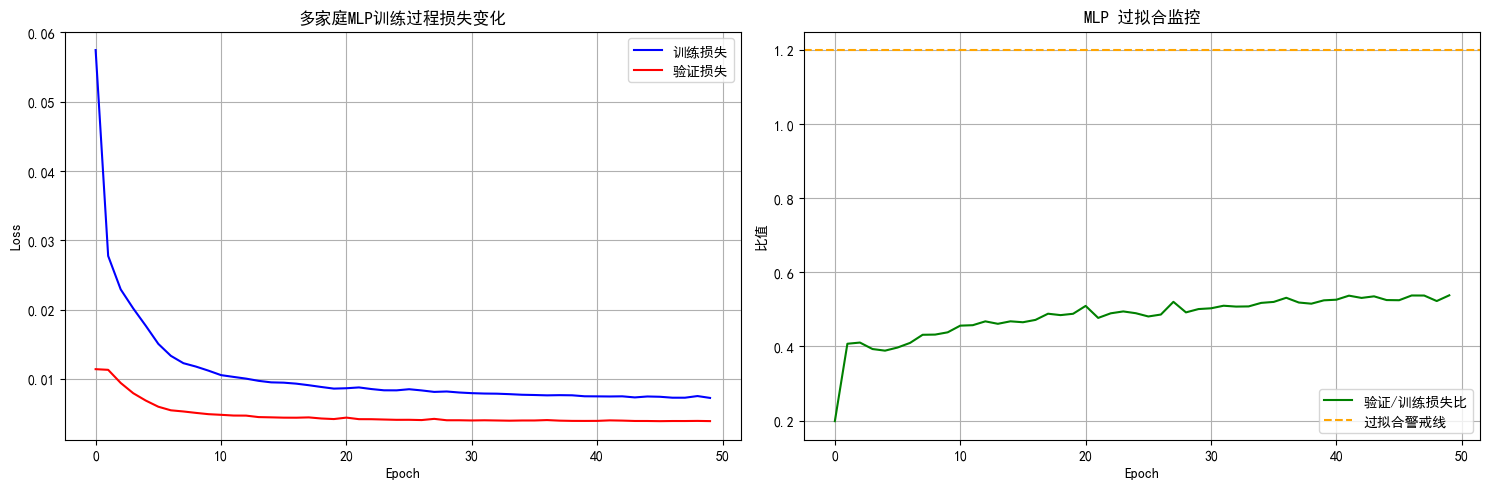


加载并评估多家庭MLP模型...
按家庭分别进行反归一化 (MLP)...
家庭 3039 (编码 0): 1728 个样本反归一化完成
家庭 3538 (编码 1): 1728 个样本反归一化完成
家庭 4031 (编码 2): 1728 个样本反归一化完成
家庭 6139 (编码 3): 1728 个样本反归一化完成
家庭 661 (编码 4): 1728 个样本反归一化完成
家庭 7951 (编码 5): 1728 个样本反归一化完成
家庭 8386 (编码 6): 1728 个样本反归一化完成
家庭 8565 (编码 7): 1728 个样本反归一化完成
家庭 9278 (编码 8): 1728 个样本反归一化完成
家庭 9922 (编码 9): 1728 个样本反归一化完成
共 17280 个预测样本
10 个不同家庭
按家庭分别进行反归一化 (MLP)...
家庭 3039 (编码 0): 1728 个样本反归一化完成
家庭 3538 (编码 1): 1728 个样本反归一化完成
家庭 4031 (编码 2): 1728 个样本反归一化完成
家庭 6139 (编码 3): 1728 个样本反归一化完成
家庭 661 (编码 4): 1728 个样本反归一化完成
家庭 7951 (编码 5): 1728 个样本反归一化完成
家庭 8386 (编码 6): 1728 个样本反归一化完成
家庭 8565 (编码 7): 1728 个样本反归一化完成
家庭 9278 (编码 8): 1728 个样本反归一化完成
家庭 9922 (编码 9): 1728 个样本反归一化完成
共 17280 个预测样本
10 个不同家庭


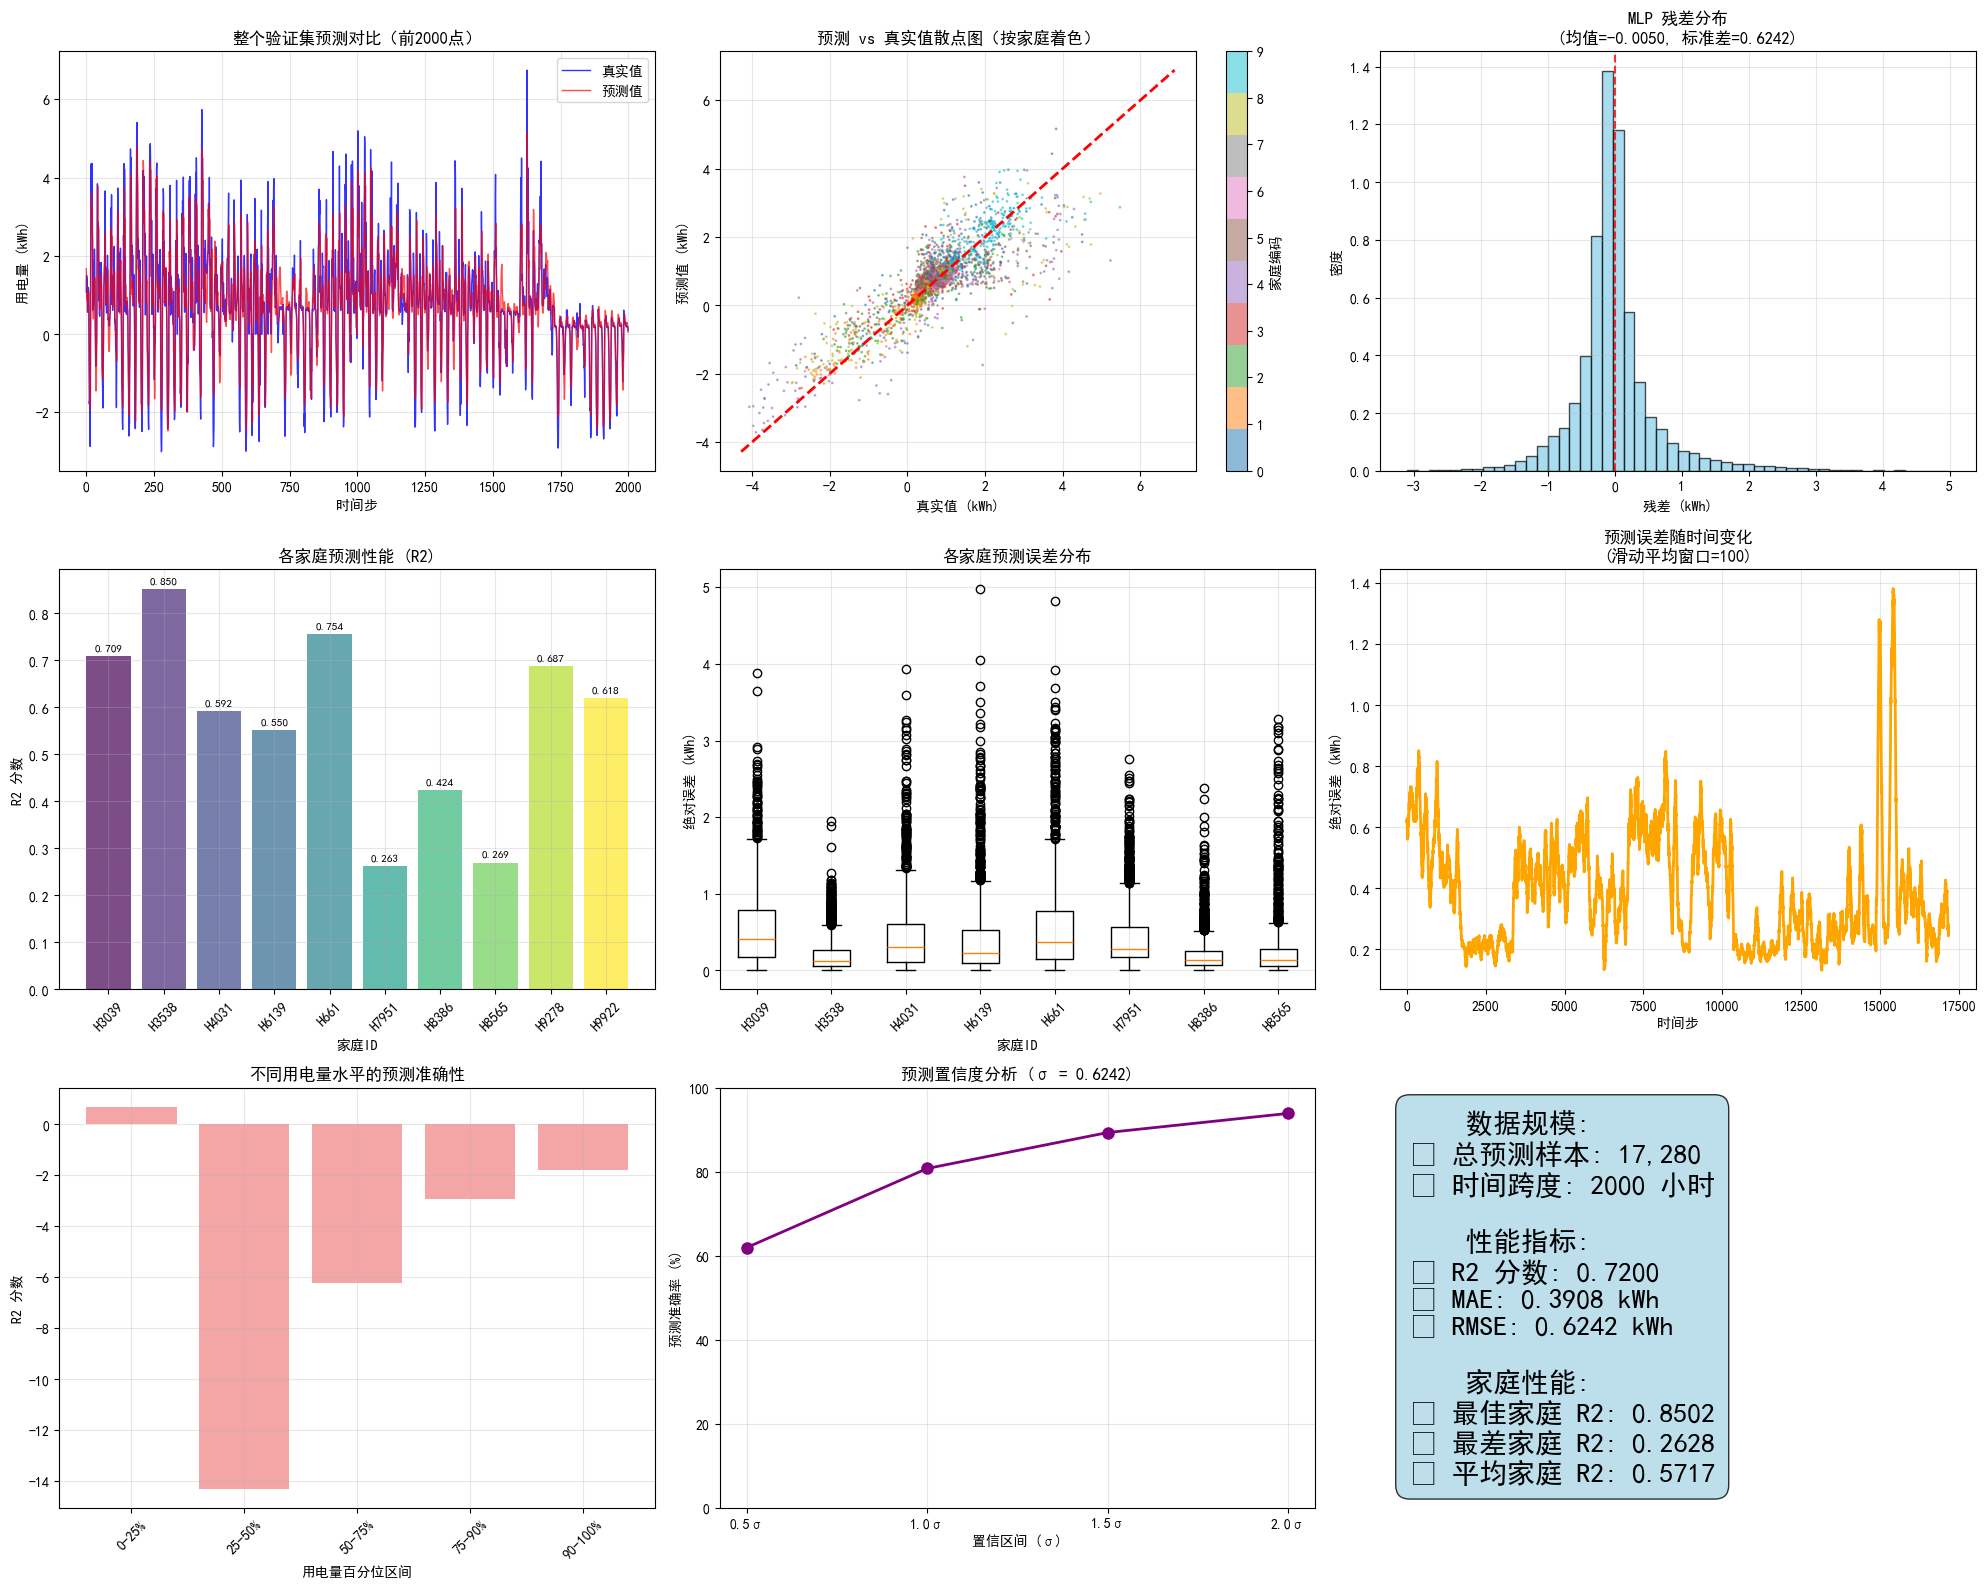


=== 详细家庭级别分析（MLP） ===


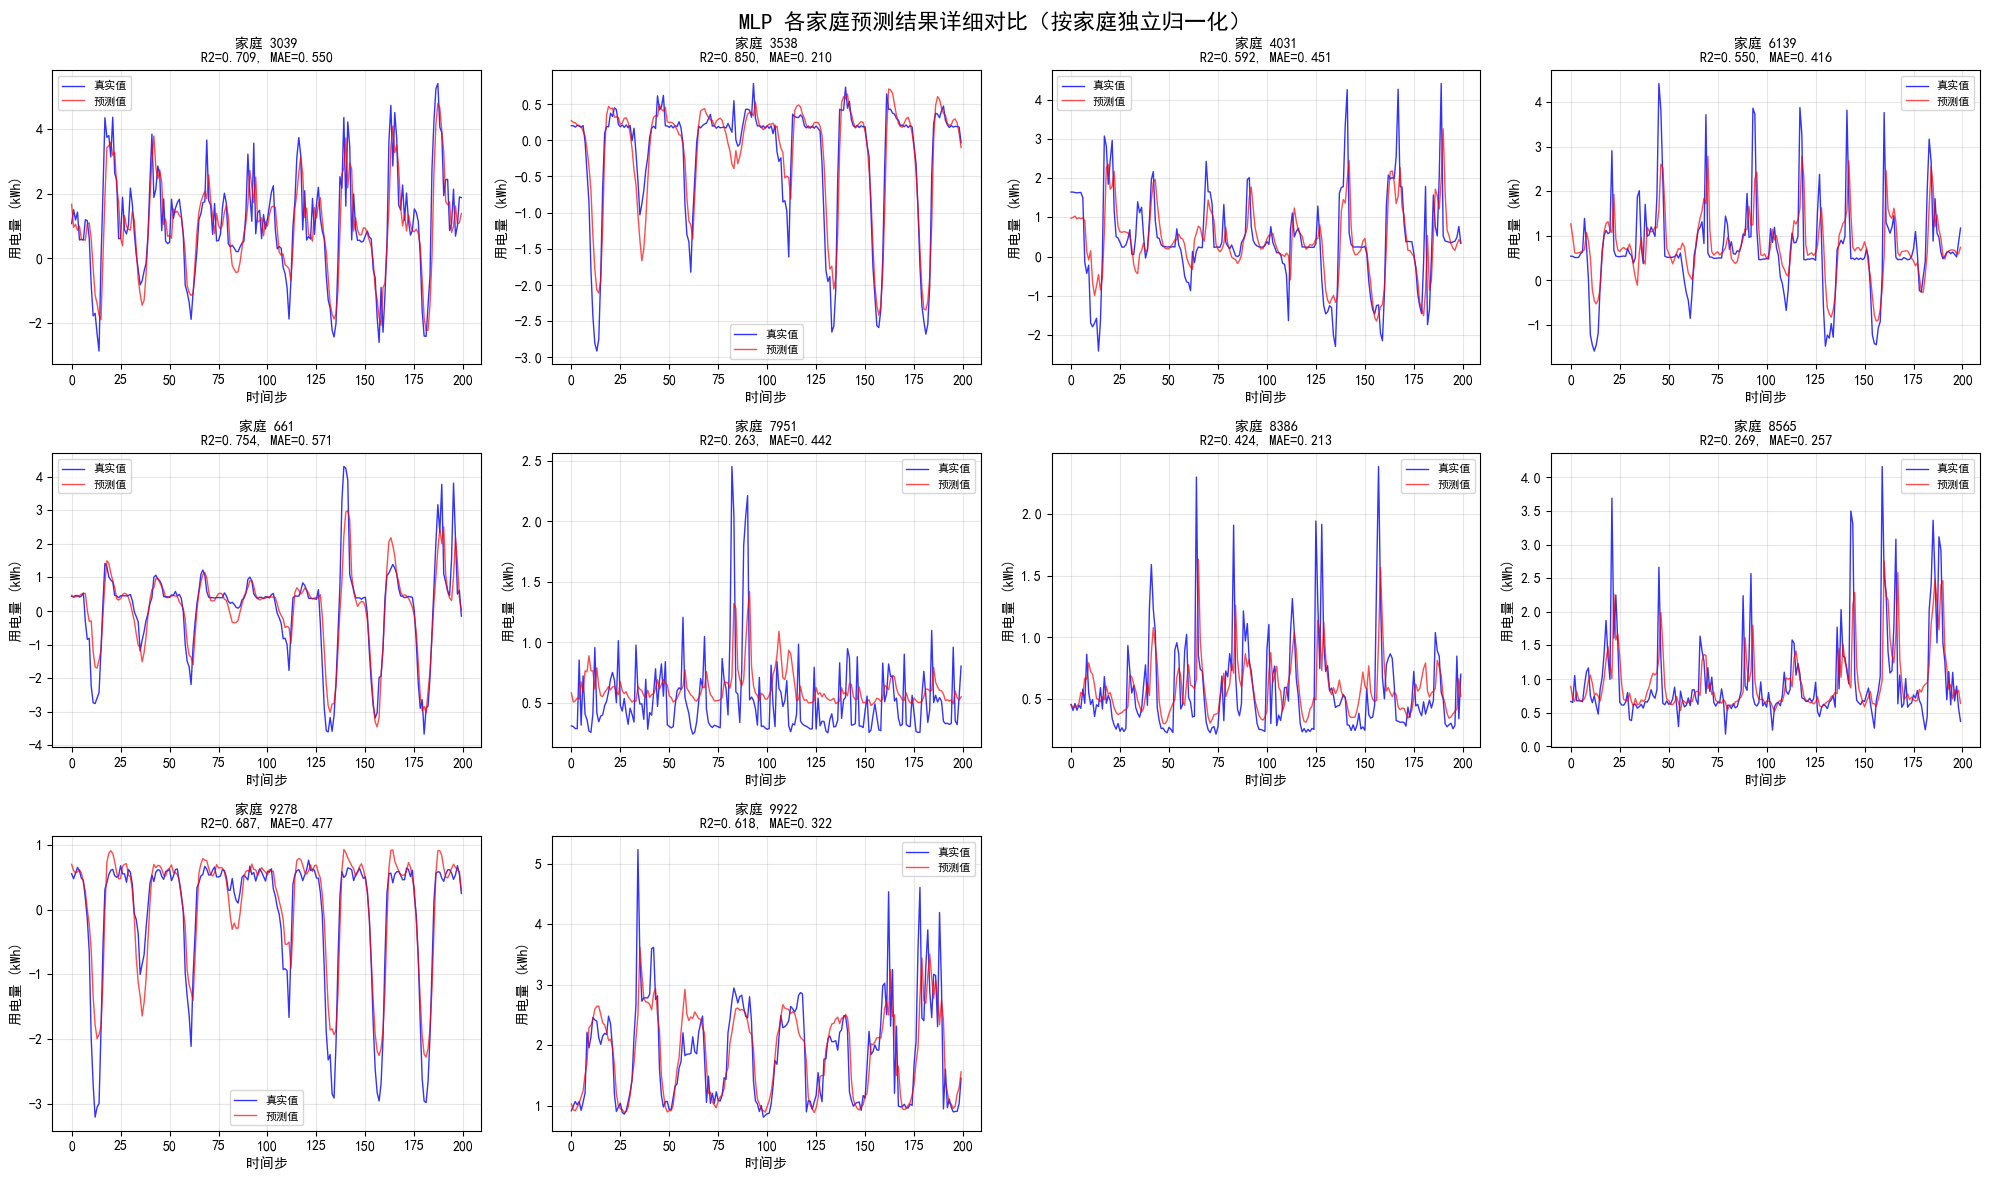


=== 详细数值分析报告（MLP，按家庭独立归一化）===
家庭ID     样本数      R2分数       MAE        RMSE       平均用电       用电范围           
-------------------------------------------------------------------------------------
3039     1728     0.7088     0.5504     0.7551     0.8844     -3.00-6.75     
3538     1728     0.8502     0.2096     0.3195     -0.1208    -2.95-1.60     
4031     1728     0.5916     0.4515     0.6721     0.4577     -2.41-4.97     
6139     1728     0.5503     0.4163     0.6760     0.7072     -2.11-6.89     
661      1728     0.7544     0.5708     0.8440     0.3323     -4.29-6.18     
7951     1728     0.2628     0.4416     0.6123     0.8936     0.00-3.87      
8386     1728     0.4243     0.2126     0.3320     0.6495     0.00-3.61      
8565     1728     0.2692     0.2566     0.4801     0.8660     -0.00-4.40     
9278     1728     0.6866     0.4769     0.7854     0.4524     -3.21-5.30     
9922     1728     0.6184     0.3218     0.5203     1.9367     0.00-6.10      

=== MLP 总体统计 ===
总体 R2 分

In [11]:
# 多家庭MLP模型评估
if os.path.exists(mlp_best_model_path):
    mlp_model.load_state_dict(torch.load(mlp_best_model_path))
    print(f'已加载最优MLP模型参数: {mlp_best_model_path}')
else:
    print('未找到已保存的MLP模型权重，将使用当前内存中的模型。')

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_train_losses, label='训练损失', color='blue')
plt.plot(mlp_val_losses, label='验证损失', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('多家庭MLP训练过程损失变化')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
if mlp_val_losses and mlp_train_losses:
    mlp_overfitting_ratio = [v / t if t > 0 else 1 for t, v in zip(mlp_train_losses, mlp_val_losses)]
    plt.plot(mlp_overfitting_ratio, label='验证/训练损失比', color='green')
    plt.axhline(y=1.2, color='orange', linestyle='--', label='过拟合警戒线')
    plt.xlabel('Epoch')
    plt.ylabel('比值')
    plt.title('MLP 过拟合监控')
    plt.legend()
else:
    plt.text(0.5, 0.5, '无训练记录', ha='center', va='center')
plt.grid(True)
plt.tight_layout()
plt.show()

mlp_model.eval()
print('\n加载并评估多家庭MLP模型...')
mlp_predictions = []
mlp_targets = []
mlp_household_ids = []
mlp_sequences = []

with torch.no_grad():
    for x, household_ids, y in val_loader:
        x = x.to(device)
        household_ids = household_ids.to(device)
        preds = mlp_model(x, household_ids).squeeze(-1)
        mlp_predictions.extend(preds.cpu().numpy())
        mlp_targets.extend(y.numpy())
        mlp_household_ids.extend(household_ids.cpu().numpy())
        mlp_sequences.extend(x.cpu().numpy())

mlp_predictions = np.array(mlp_predictions)
mlp_targets = np.array(mlp_targets)
mlp_household_ids = np.array(mlp_household_ids)
mlp_sequences = np.array(mlp_sequences)

print('按家庭分别进行反归一化 (MLP)...')
mlp_predictions_original = np.zeros_like(mlp_predictions)
mlp_targets_original = np.zeros_like(mlp_targets)
mlp_household_id_mapping = {code: household_id for code, household_id in enumerate(valid_households)}

for household_code in np.unique(mlp_household_ids):
    mask = mlp_household_ids == household_code
    original_household_id = mlp_household_id_mapping[household_code]
    scaler = household_scalers[original_household_id]
    h_preds = mlp_predictions[mask].reshape(-1, 1)
    h_targets = mlp_targets[mask].reshape(-1, 1)
    mlp_predictions_original[mask] = scaler.inverse_transform(h_preds).flatten()
    mlp_targets_original[mask] = scaler.inverse_transform(h_targets).flatten()
    print(f'家庭 {original_household_id} (编码 {household_code}): {np.sum(mask)} 个样本反归一化完成')

print(f'共 {len(mlp_predictions_original)} 个预测样本')
print(f'{len(np.unique(mlp_household_ids))} 个不同家庭')

plt.figure(figsize=(20, 16))

plt.subplot(3, 3, 1)
display_points = min(2000, len(mlp_predictions_original))
time_indices = np.arange(display_points)
if display_points > 0:
    plt.plot(time_indices, mlp_targets_original[:display_points], label='真实值', color='blue', alpha=0.8, linewidth=1)
    plt.plot(time_indices, mlp_predictions_original[:display_points], label='预测值', color='red', alpha=0.7, linewidth=1)
    plt.xlabel('时间步')
    plt.ylabel('用电量 (kWh)')
    plt.title(f'整个验证集预测对比（前{display_points}点）')
    plt.legend()
else:
    plt.text(0.5, 0.5, '无数据', ha='center', va='center')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 2)
if len(mlp_predictions_original) > 0:
    sample_indices = np.random.choice(len(mlp_predictions_original), min(3000, len(mlp_predictions_original)), replace=False)
    scatter = plt.scatter(mlp_targets_original[sample_indices], mlp_predictions_original[sample_indices],
                          alpha=0.5, s=1, c=mlp_household_ids[sample_indices], cmap='tab10')
    plt.plot([mlp_targets_original.min(), mlp_targets_original.max()],
             [mlp_targets_original.min(), mlp_targets_original.max()], 'r--', lw=2)
    plt.colorbar(scatter, label='家庭编码')
else:
    plt.text(0.5, 0.5, '无数据', ha='center', va='center')
plt.xlabel('真实值 (kWh)')
plt.ylabel('预测值 (kWh)')
plt.title('预测 vs 真实值散点图（按家庭着色）')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 3)
mlp_residuals = mlp_targets_original - mlp_predictions_original
if len(mlp_residuals) > 0:
    plt.hist(mlp_residuals, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.8)
else:
    plt.text(0.5, 0.5, '无数据', ha='center', va='center')
plt.xlabel('残差 (kWh)')
plt.ylabel('密度')
plt.title(f'MLP 残差分布\n(均值={np.mean(mlp_residuals):.4f}, 标准差={np.std(mlp_residuals):.4f})')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 4)
unique_mlp_household_codes = np.unique(mlp_household_ids)
mlp_household_performance = {}
for household_code in unique_mlp_household_codes:
    mask = mlp_household_ids == household_code
    if np.sum(mask) > 10:
        h_targets = mlp_targets_original[mask]
        h_preds = mlp_predictions_original[mask]
        h_r2 = r2_score(h_targets, h_preds)
        h_mae = mean_absolute_error(h_targets, h_preds)
        original_household_id = mlp_household_id_mapping[household_code]
        mlp_household_performance[original_household_id] = {
            'r2': h_r2,
            'mae': h_mae,
            'count': len(h_targets),
            'code': household_code
        }
mlp_household_ids_list = list(mlp_household_performance.keys())
mlp_r2_scores = [mlp_household_performance[hid]['r2'] for hid in mlp_household_ids_list]
if mlp_household_ids_list:
    bars = plt.bar(range(len(mlp_household_ids_list)), mlp_r2_scores,
                   color=plt.cm.viridis(np.linspace(0, 1, len(mlp_household_ids_list))), alpha=0.7)
    plt.xticks(range(len(mlp_household_ids_list)), [f'H{hid}' for hid in mlp_household_ids_list], rotation=45)
    for bar, score in zip(bars, mlp_r2_scores):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{score:.3f}', ha='center', va='bottom', fontsize=8)
else:
    plt.text(0.5, 0.5, '样本数不足', ha='center', va='center', fontsize=12)
plt.xlabel('家庭ID')
plt.ylabel('R2 分数')
plt.title('各家庭预测性能 (R2)')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 5)
mlp_household_errors = []
mlp_household_labels = []
for hid in mlp_household_ids_list[:8]:
    household_code = mlp_household_performance[hid]['code']
    mask = mlp_household_ids == household_code
    if np.sum(mask) > 10:
        errors = np.abs(mlp_targets_original[mask] - mlp_predictions_original[mask])
        mlp_household_errors.append(errors)
        mlp_household_labels.append(f'H{hid}')
if mlp_household_errors:
    plt.boxplot(mlp_household_errors, labels=mlp_household_labels)
else:
    plt.text(0.5, 0.5, '样本数不足', ha='center', va='center', fontsize=12)
plt.ylabel('绝对误差 (kWh)')
plt.xlabel('家庭ID')
plt.title('各家庭预测误差分布')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 6)
abs_errors = np.abs(mlp_residuals)
window_size = 100
if len(abs_errors) > window_size:
    smoothed_errors = np.convolve(abs_errors, np.ones(window_size) / window_size, mode='valid')
    plt.plot(smoothed_errors, color='orange', linewidth=2)
elif len(abs_errors) > 0:
    plt.plot(abs_errors, color='orange', linewidth=1)
else:
    plt.text(0.5, 0.5, '无数据', ha='center', va='center')
plt.xlabel('时间步')
plt.ylabel('绝对误差 (kWh)')
plt.title(f'预测误差随时间变化\n(滑动平均窗口={window_size})')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 7)
if len(mlp_targets_original) > 0:
    percentiles = [0, 25, 50, 75, 90, 100]
    quantiles = np.percentile(mlp_targets_original, percentiles)
    interval_r2 = []
    interval_labels = []
    for idx in range(len(quantiles) - 1):
        mask = (mlp_targets_original >= quantiles[idx]) & (mlp_targets_original < quantiles[idx + 1])
        if np.sum(mask) > 10:
            interval_targets = mlp_targets_original[mask]
            interval_preds = mlp_predictions_original[mask]
            interval_r2.append(r2_score(interval_targets, interval_preds))
            interval_labels.append(f'{percentiles[idx]}-{percentiles[idx + 1]}%')
    if interval_r2:
        plt.bar(range(len(interval_r2)), interval_r2, color='lightcoral', alpha=0.7)
        plt.xticks(range(len(interval_labels)), interval_labels, rotation=45)
    else:
        plt.text(0.5, 0.5, '样本数不足', ha='center', va='center', fontsize=12)
else:
    plt.text(0.5, 0.5, '无数据', ha='center', va='center', fontsize=12)
plt.xlabel('用电量百分位区间')
plt.ylabel('R2 分数')
plt.title('不同用电量水平的预测准确性')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 8)
mlp_residual_std = np.std(mlp_residuals) if len(mlp_residuals) > 0 else 0.0
confidence_sigmas = [0.5, 1.0, 1.5, 2.0]
confidence_intervals = [mlp_residual_std * sigma for sigma in confidence_sigmas]
accuracy_within_ci = []
for ci, sigma in zip(confidence_intervals, confidence_sigmas):
    if len(mlp_residuals) > 0 and mlp_residual_std > 0:
        within_ci = np.sum(np.abs(mlp_residuals) <= ci) / len(mlp_residuals) * 100
    elif len(mlp_residuals) > 0:
        within_ci = 100.0
    else:
        within_ci = 0.0
    accuracy_within_ci.append(within_ci)
plt.plot([f'{sigma:.1f}σ' for sigma in confidence_sigmas], accuracy_within_ci,
         marker='o', linewidth=2, markersize=8, color='purple')
plt.xlabel('置信区间 (σ)')
plt.ylabel('预测准确率 (%)')
plt.title(f'预测置信度分析 (σ = {mlp_residual_std:.4f})')
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

plt.subplot(3, 3, 9)
plt.axis('off')
mlp_overall_r2 = r2_score(mlp_targets_original, mlp_predictions_original) if len(mlp_targets_original) > 0 else float('nan')
mlp_overall_mae = mean_absolute_error(mlp_targets_original, mlp_predictions_original) if len(mlp_targets_original) > 0 else float('nan')
mlp_overall_rmse = np.sqrt(mean_squared_error(mlp_targets_original, mlp_predictions_original)) if len(mlp_targets_original) > 0 else float('nan')
if mlp_r2_scores:
    mlp_best_r2 = max(mlp_r2_scores)
    mlp_worst_r2 = min(mlp_r2_scores)
    mlp_mean_r2 = float(np.mean(mlp_r2_scores))
else:
    mlp_best_r2 = float('nan')
    mlp_worst_r2 = float('nan')
    mlp_mean_r2 = float('nan')
summary_lines = [
    '    数据规模:',
    f'• 总预测样本: {len(mlp_predictions_original):,}',
    f'• 时间跨度: {display_points} 小时',
    '',
    '    性能指标:',
    f'• R2 分数: {mlp_overall_r2:.4f}',
    f'• MAE: {mlp_overall_mae:.4f} kWh',
    f'• RMSE: {mlp_overall_rmse:.4f} kWh',
    '',
    '    家庭性能:',
    f'• 最佳家庭 R2: {mlp_best_r2:.4f}',
    f'• 最差家庭 R2: {mlp_worst_r2:.4f}',
    f'• 平均家庭 R2: {mlp_mean_r2:.4f}'
 ]
summary_text = '\n'.join(summary_lines)
plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes,
         fontsize=20, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

print('\n=== 详细家庭级别分析（MLP） ===')
if mlp_household_ids_list:
    plt.figure(figsize=(20, 12))
    sorted_mlp_households = sorted(mlp_household_ids_list, key=lambda hid: mlp_household_performance[hid]['code'])
    max_households_to_show = min(12, len(sorted_mlp_households))
    cols = 4
    rows = (max_households_to_show + cols - 1) // cols if max_households_to_show > 0 else 1
    for idx, hid in enumerate(sorted_mlp_households[:max_households_to_show]):
        plt.subplot(rows, cols, idx + 1)
        household_code = mlp_household_performance[hid]['code']
        mask = mlp_household_ids == household_code
        h_targets = mlp_targets_original[mask]
        h_preds = mlp_predictions_original[mask]
        display_len = min(200, len(h_targets))
        if display_len > 0:
            plt.plot(h_targets[:display_len], label='真实值', color='blue', alpha=0.8, linewidth=1)
            plt.plot(h_preds[:display_len], label='预测值', color='red', alpha=0.7, linewidth=1)
        else:
            plt.text(0.5, 0.5, '无数据', ha='center', va='center')
        h_r2 = mlp_household_performance[hid]['r2']
        h_mae = mlp_household_performance[hid]['mae']
        plt.title(f'家庭 {hid}\nR2={h_r2:.3f}, MAE={h_mae:.3f}', fontsize=10)
        plt.xlabel('时间步')
        plt.ylabel('用电量 (kWh)')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3)
    plt.suptitle('MLP 各家庭预测结果详细对比（按家庭独立归一化）', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print('MLP 模型在验证集中缺少足够的家庭样本用于可视化。')

print('\n=== 详细数值分析报告（MLP，按家庭独立归一化）===')
print(f'{"家庭ID":<8} {"样本数":<8} {"R2分数":<10} {"MAE":<10} {"RMSE":<10} {"平均用电":<10} {"用电范围":<15}')
print('-' * 85)
for hid in sorted(mlp_household_ids_list):
    household_code = mlp_household_performance[hid]['code']
    mask = mlp_household_ids == household_code
    h_targets = mlp_targets_original[mask]
    h_preds = mlp_predictions_original[mask]
    h_r2 = r2_score(h_targets, h_preds)
    h_mae = mean_absolute_error(h_targets, h_preds)
    h_rmse = np.sqrt(mean_squared_error(h_targets, h_preds))
    h_mean_consumption = np.mean(h_targets)
    h_range = f'{h_targets.min():.2f}-{h_targets.max():.2f}'
    print(f'{hid:<8} {len(h_targets):<8} {h_r2:<10.4f} {h_mae:<10.4f} {h_rmse:<10.4f} {h_mean_consumption:<10.4f} {h_range:<15}')

print('\n=== MLP 总体统计 ===')
if len(mlp_targets_original) > 0:
    overall_r2 = r2_score(mlp_targets_original, mlp_predictions_original)
    overall_mae = mean_absolute_error(mlp_targets_original, mlp_predictions_original)
    overall_rmse = np.sqrt(mean_squared_error(mlp_targets_original, mlp_predictions_original))
    print(f'总体 R2 分数: {overall_r2:.6f}')
    print(f'总体 MAE: {overall_mae:.6f} kWh')
    print(f'总体 RMSE: {overall_rmse:.6f} kWh')
    print(f'预测值范围: {mlp_predictions_original.min():.4f} - {mlp_predictions_original.max():.4f} kWh')
    print(f'真实值范围: {mlp_targets_original.min():.4f} - {mlp_targets_original.max():.4f} kWh')
    print(f'残差范围: {mlp_residuals.min():.4f} - {mlp_residuals.max():.4f} kWh')
else:
    print('验证集上没有可用于统计的样本。')

print('\n=== 各家庭归一化器信息 ===')
for household_id in valid_households:
    scaler = household_scalers[household_id]
    data_min = scaler.data_min_[0]
    data_max = scaler.data_max_[0]
    data_range = scaler.data_range_[0]
    print(f'家庭 {household_id}: 最小值={data_min:.4f}, 最大值={data_max:.4f}, 范围={data_range:.4f}')

In [12]:
# cuML SVR 与 随机森林预测
import cupy as cp
import numpy as np
from cuml.svm import SVR as cuSVR
from cuml.ensemble import RandomForestRegressor as cuRF
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def dataset_to_numpy(dataset):
    seq_len = dataset.seq_len
    X = np.zeros((len(dataset), seq_len + 1), dtype=np.float32)
    y = np.zeros(len(dataset), dtype=np.float32)
    households = np.zeros(len(dataset), dtype=np.int64)
    for idx in range(len(dataset)):
        seq, household_id, target = dataset[idx]
        seq_np = seq.cpu().numpy()
        X[idx, :seq_len] = seq_np
        X[idx, -1] = float(household_id.item())
        y[idx] = target.item()
        households[idx] = int(household_id.item())
    return X, y, households

train_X_np, train_y_np, train_households = dataset_to_numpy(train_dataset)
val_X_np, val_y_np, val_households = dataset_to_numpy(val_dataset)

train_X = cp.asarray(train_X_np)
train_y = cp.asarray(train_y_np)
val_X = cp.asarray(val_X_np)

svr_model = cuSVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
svr_model.fit(train_X, train_y)
svr_preds_norm = cp.asnumpy(svr_model.predict(val_X))

rf_model = cuRF(n_estimators=300, max_depth=18, random_state=42, n_streams=8)
rf_model.fit(train_X, train_y)
rf_preds_norm = cp.asnumpy(rf_model.predict(val_X))

household_id_mapping = {code: household_id for code, household_id in enumerate(valid_households)}

def inverse_predictions(preds_norm, targets_norm, household_codes):
    preds_original = np.zeros_like(preds_norm)
    targets_original = np.zeros_like(targets_norm)
    for code in np.unique(household_codes):
        mask = household_codes == code
        household_id = household_id_mapping[code]
        scaler = household_scalers[household_id]
        preds_original[mask] = scaler.inverse_transform(preds_norm[mask].reshape(-1, 1)).flatten()
        targets_original[mask] = scaler.inverse_transform(targets_norm[mask].reshape(-1, 1)).flatten()
    return preds_original, targets_original

svr_preds_original, targets_original = inverse_predictions(svr_preds_norm, val_y_np, val_households)
rf_preds_original, _ = inverse_predictions(rf_preds_norm, val_y_np, val_households)

def report_metrics(name, preds, targets):
    r2 = r2_score(targets, preds)
    mae = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    print(f"{name} -> R2: {r2:.6f} | MAE: {mae:.6f} kWh | RMSE: {rmse:.6f} kWh")

print('\n=== cuML 模型评估 (验证集) ===')
report_metrics('SVR', svr_preds_original, targets_original)
report_metrics('RandomForest', rf_preds_original, targets_original)


=== cuML 模型评估 (验证集) ===
SVR -> R2: 0.701005 | MAE: 0.446784 kWh | RMSE: 0.644994 kWh
RandomForest -> R2: 0.740857 | MAE: 0.360805 kWh | RMSE: 0.600474 kWh



开始基于 ARIMA 的预测...

=== ARIMA 模型评估 (验证集) ===
R2: 0.030820
MAE: 0.773799 kWh
RMSE: 1.156903 kWh
总评估样本数: 17520

=== ARIMA 模型评估 (验证集) ===
R2: 0.030820
MAE: 0.773799 kWh
RMSE: 1.156903 kWh
总评估样本数: 17520


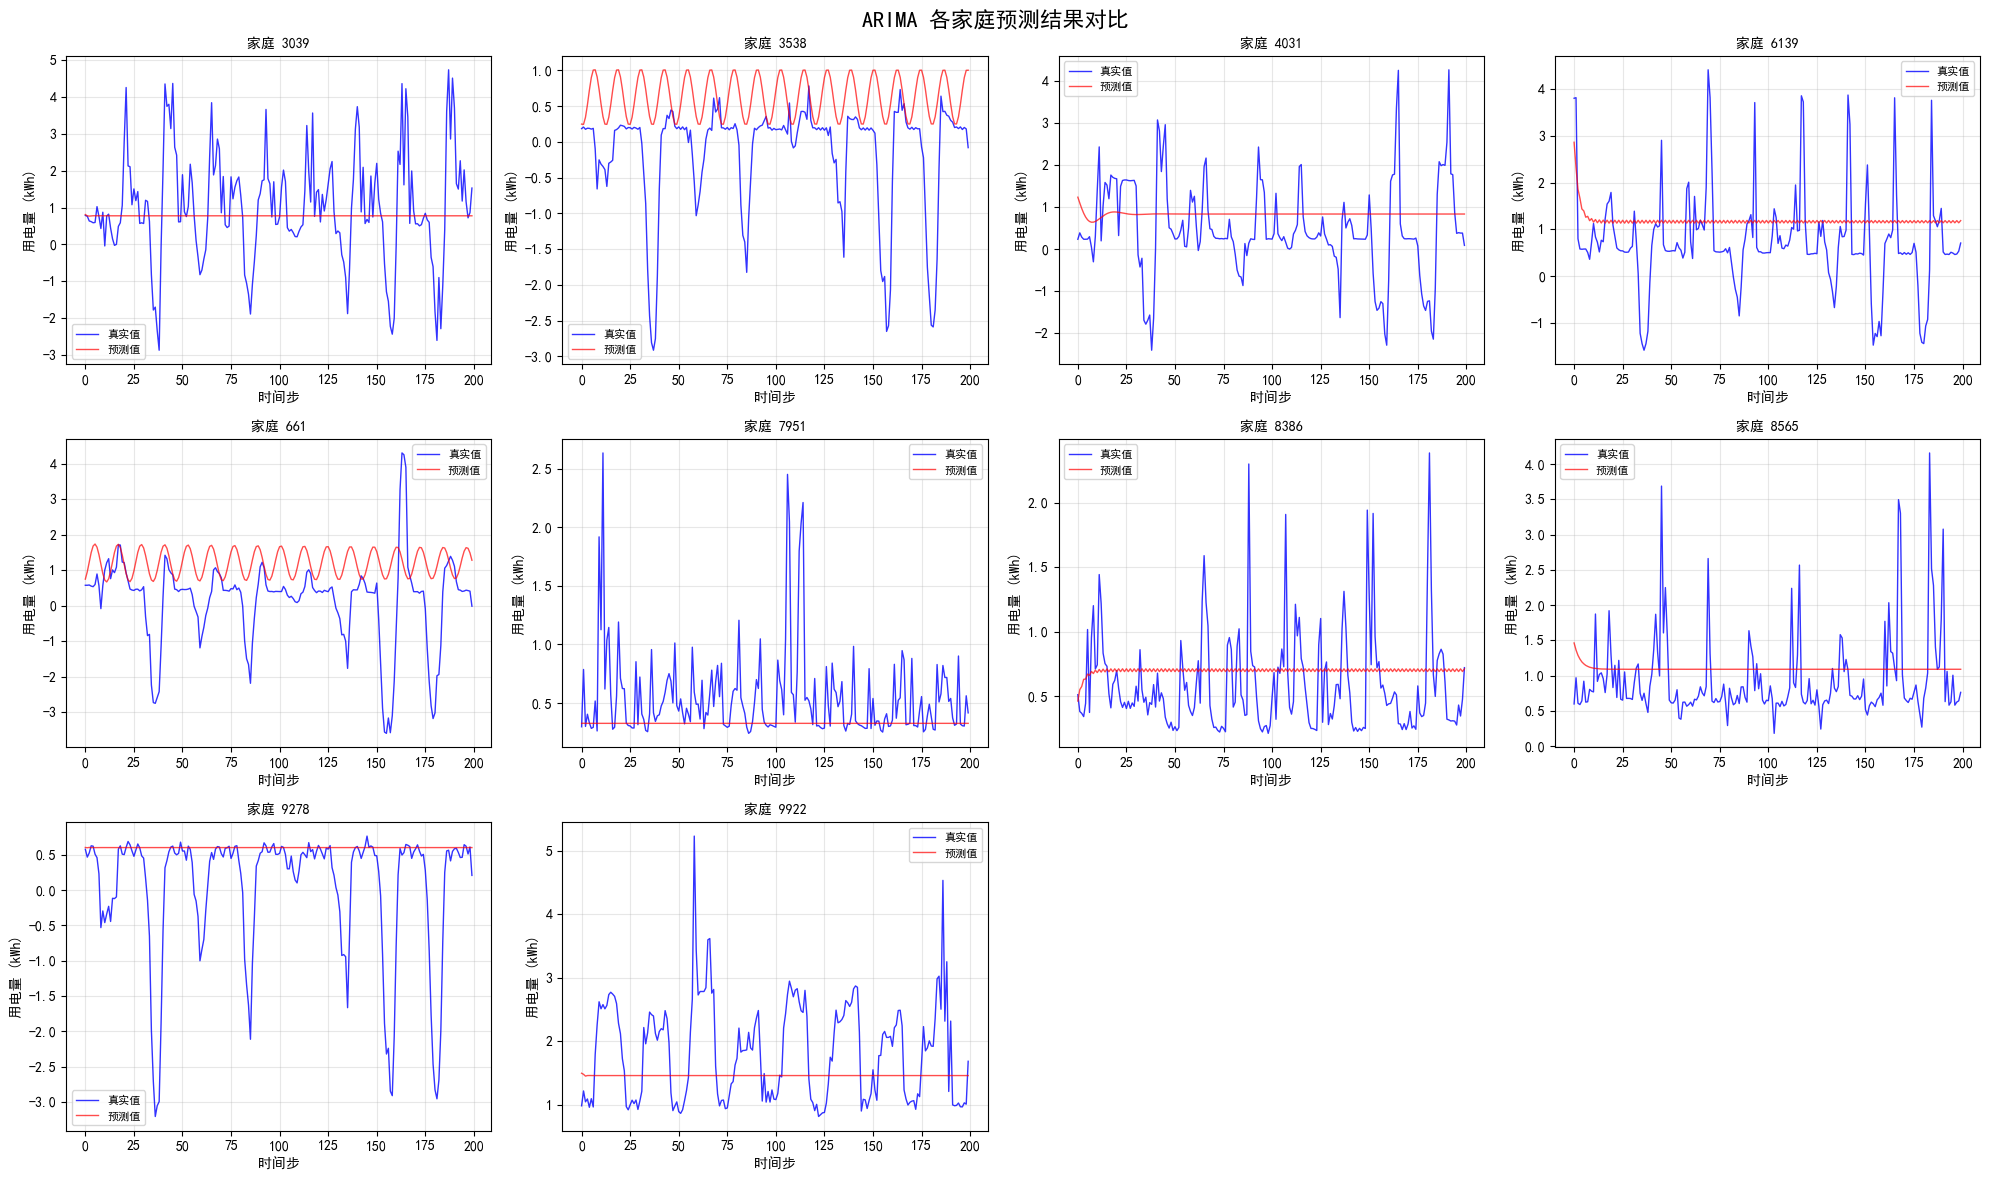

In [13]:
# ARIMA 基线预测
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

arima_predictions = []
arima_targets = []
arima_household_codes = []

print('\n开始基于 ARIMA 的预测...')
for household_code, household_id in enumerate(valid_households):
    df_sub = data[data['dataid'] == household_id].copy()
    if df_sub.empty:
        continue
    df_sub = df_sub.sort_values('local_15min')
    series = df_sub['grid'].astype(float)
    if series.isna().any():
        series = series.fillna(method='ffill').fillna(method='bfill')
    values = series.values
    n_samples = len(values)
    if n_samples <= 2:
        continue
    train_size = int(n_samples * 0.8)
    if train_size == 0 or train_size == n_samples:
        continue
    train_series = values[:train_size]
    val_series = values[train_size:]
    if len(val_series) == 0:
        continue
    forecast = None
    for order in [(2,1,2), (1,1,1), (1,0,0)]:
        try:
            model = ARIMA(train_series, order=order)
            fitted = model.fit()
            forecast = fitted.forecast(steps=len(val_series))
            break
        except Exception as err:
            continue
    if forecast is None:
        print(f'家庭 {household_id} 的 ARIMA 拟合失败，跳过。')
        continue
    arima_predictions.extend(np.asarray(forecast))
    arima_targets.extend(val_series)
    arima_household_codes.extend([household_code] * len(val_series))

arima_predictions = np.array(arima_predictions)
arima_targets = np.array(arima_targets)
arima_household_codes = np.array(arima_household_codes)

if len(arima_predictions) == 0:
    print('ARIMA 基线未产生有效预测结果，请检查数据或参数设置。')
else:
    arima_r2 = r2_score(arima_targets, arima_predictions)
    arima_mae = mean_absolute_error(arima_targets, arima_predictions)
    arima_rmse = np.sqrt(mean_squared_error(arima_targets, arima_predictions))
    print('\n=== ARIMA 模型评估 (验证集) ===')
    print(f'R2: {arima_r2:.6f}')
    print(f'MAE: {arima_mae:.6f} kWh')
    print(f'RMSE: {arima_rmse:.6f} kWh')
    print(f'总评估样本数: {len(arima_predictions)}')
    unique_codes = np.unique(arima_household_codes)
    if len(unique_codes) > 0:
        max_households_to_show = min(12, len(unique_codes))
        cols = 4
        rows = (max_households_to_show + cols - 1) // cols
        plt.figure(figsize=(20, 12))
        for idx, code in enumerate(unique_codes[:max_households_to_show]):
            plt.subplot(rows, cols, idx + 1)
            mask = arima_household_codes == code
            household_id = valid_households[code]
            h_targets = arima_targets[mask]
            h_preds = arima_predictions[mask]
            display_len = min(200, len(h_targets))
            plt.plot(h_targets[:display_len], label='真实值', color='blue', alpha=0.8, linewidth=1)
            plt.plot(h_preds[:display_len], label='预测值', color='red', alpha=0.7, linewidth=1)
            plt.title(f'家庭 {household_id}', fontsize=10)
            plt.xlabel('时间步')
            plt.ylabel('用电量 (kWh)')
            plt.legend(fontsize=8)
            plt.grid(True, alpha=0.3)
        plt.suptitle('ARIMA 各家庭预测结果对比', fontsize=16, y=0.98)
        plt.tight_layout()
        plt.show()

In [14]:
# Naïve 持久性基线预测
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

naive_predictions = []
naive_targets = []
naive_household_codes = []

print('\n开始计算 Naïve 基线 (上一时刻持久性预测)...')
for x, household_ids, y in val_loader:
    # x: [batch_size, seq_len], y: [batch_size]
    last_observation = x[:, -1].numpy()
    naive_predictions.extend(last_observation)
    naive_targets.extend(y.numpy())
    naive_household_codes.extend(household_ids.numpy())

naive_predictions = np.array(naive_predictions)
naive_targets = np.array(naive_targets)
naive_household_codes = np.array(naive_household_codes)

print('按家庭分别进行反归一化 (Naïve)...')
naive_preds_original = np.zeros_like(naive_predictions)
naive_targets_original = np.zeros_like(naive_targets)
household_id_mapping = {code: household_id for code, household_id in enumerate(valid_households)}

for household_code in np.unique(naive_household_codes):
    mask = naive_household_codes == household_code
    household_id = household_id_mapping[household_code]
    scaler = household_scalers[household_id]
    h_preds = naive_predictions[mask].reshape(-1, 1)
    h_targets = naive_targets[mask].reshape(-1, 1)
    naive_preds_original[mask] = scaler.inverse_transform(h_preds).flatten()
    naive_targets_original[mask] = scaler.inverse_transform(h_targets).flatten()
    print(f'家庭 {household_id} (编码 {household_code}): {np.sum(mask)} 个样本反归一化完成')

naive_r2 = r2_score(naive_targets_original, naive_preds_original)
naive_mae = mean_absolute_error(naive_targets_original, naive_preds_original)
naive_rmse = np.sqrt(mean_squared_error(naive_targets_original, naive_preds_original))

print('\n=== Naïve 基线评估 (验证集) ===')
print(f'R2: {naive_r2:.6f}')
print(f'MAE: {naive_mae:.6f} kWh')
print(f'RMSE: {naive_rmse:.6f} kWh')
print(f'总评估样本数: {len(naive_preds_original)}')


开始计算 Naïve 基线 (上一时刻持久性预测)...
按家庭分别进行反归一化 (Naïve)...
家庭 3039 (编码 0): 1728 个样本反归一化完成
家庭 3538 (编码 1): 1728 个样本反归一化完成
家庭 4031 (编码 2): 1728 个样本反归一化完成
家庭 6139 (编码 3): 1728 个样本反归一化完成
家庭 661 (编码 4): 1728 个样本反归一化完成
家庭 7951 (编码 5): 1728 个样本反归一化完成
家庭 8386 (编码 6): 1728 个样本反归一化完成
家庭 8565 (编码 7): 1728 个样本反归一化完成
家庭 9278 (编码 8): 1728 个样本反归一化完成
家庭 9922 (编码 9): 1728 个样本反归一化完成

=== Naïve 基线评估 (验证集) ===
R2: 0.620678
MAE: 0.412306 kWh
RMSE: 0.726487 kWh
总评估样本数: 17280
按家庭分别进行反归一化 (Naïve)...
家庭 3039 (编码 0): 1728 个样本反归一化完成
家庭 3538 (编码 1): 1728 个样本反归一化完成
家庭 4031 (编码 2): 1728 个样本反归一化完成
家庭 6139 (编码 3): 1728 个样本反归一化完成
家庭 661 (编码 4): 1728 个样本反归一化完成
家庭 7951 (编码 5): 1728 个样本反归一化完成
家庭 8386 (编码 6): 1728 个样本反归一化完成
家庭 8565 (编码 7): 1728 个样本反归一化完成
家庭 9278 (编码 8): 1728 个样本反归一化完成
家庭 9922 (编码 9): 1728 个样本反归一化完成

=== Naïve 基线评估 (验证集) ===
R2: 0.620678
MAE: 0.412306 kWh
RMSE: 0.726487 kWh
总评估样本数: 17280


In [15]:
# 汇总 LSTM、GRU、SVR 与 Naïve 基线的性能指标
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def compute_metrics_row(name, preds, targets):
    return {
        '模型': name,
        'R2': r2_score(targets, preds),
        'MAE (kWh)': mean_absolute_error(targets, preds),
        'RMSE (kWh)': np.sqrt(mean_squared_error(targets, preds))
    }

metrics_rows = []
models_info = [
    ('LSTM', globals().get('predictions_original'), globals().get('targets_original')),
    ('GRU', globals().get('gru_predictions_original'), globals().get('gru_targets_original')),
    ('SVR', globals().get('svr_preds_original'), globals().get('targets_original')),
    ("Naïve", globals().get('naive_preds_original'), globals().get('naive_targets_original'))
]
for name, preds, targets in models_info:
    if preds is None or targets is None:
        print(f'警告: 模型 {name} 缺少数据，已跳过。')
        continue
    preds = np.asarray(preds).reshape(-1)
    targets = np.asarray(targets).reshape(-1)
    if len(preds) == 0 or len(preds) != len(targets):
        print(f'警告: 模型 {name} 的预测与目标长度不一致，已跳过。')
        continue
    metrics_rows.append(compute_metrics_row(name, preds, targets))

if metrics_rows:
    metrics_df = pd.DataFrame(metrics_rows)
    display(metrics_df.set_index('模型').round({'R2': 6, 'MAE (kWh)': 6, 'RMSE (kWh)': 6}))
else:
    print('未生成任何指标，请检查前序单元格的执行情况。')

,R2,MAE (kWh),RMSE (kWh)
模型,,,
LSTM,0.729546,0.363141,0.613438
GRU,0.727154,0.388219,0.616145
SVR,0.701005,0.446784,0.644994
Naïve,0.620678,0.412306,0.726487
